# Intent and sentiment aware information retrieval
Hybrid financial IR pipeline combining BM25, neural re-ranking, and sentiment-aware diversity re-ranking for non-expert financial Q&A - built on PyTerrier & BEIR/FiQA.

## Downloading the collection

Using ir_datasets
Source: https://ir-datasets.com/beir.html#beir/fiqa

In [ ]:
!pip install python-terrier langdetect tqdm sentence-transformers openpyxl
!pip install -q transformers accelerate bitsandbytes
!pip install --upgrade -q git+https://github.com/terrierteam/pyterrier_doc2query.git

# Get the glossary from Github
!wget -q https://github.com/stalidzane/intent-and-sentiment-aware-information-retrieval/raw/main/assets/GLOSSARY_Budget_Finance_Acronyms_Jan2022.xlsx
# Get (previously computed) the expanded docs from Github
!wget -q https://github.com/stalidzane/intent-and-sentiment-aware-information-retrieval/raw/main/assets/expanded_docs.parquet
# Get the (previously computed) rewritten queries from Github
!wget -q https://github.com/stalidzane/intent-and-sentiment-aware-information-retrieval/raw/main/assets/rewritten_queries.parquet

import pyterrier as pt
from langdetect import detect, LangDetectException
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import os
import shutil
import torch
import random
from tqdm import tqdm
from pyterrier_doc2query import Doc2Query
from sentence_transformers import CrossEncoder
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM
import numpy as np
from collections import defaultdict
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import wordnet as wn
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
stop_words = set(stopwords.words('english'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.1/866.1 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.0/149.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 85.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=99322

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# Collection

In [2]:
dataset = pt.get_dataset('irds:beir/fiqa/test')

In [3]:
for doc in dataset.get_corpus_iter():
    print(doc.keys())
    print(doc)
    break

[INFO] [starting] building docstore
[INFO] [starting] opening zip file
[INFO] If you have a local copy of https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip, you can symlink it here to avoid downloading it again: /root/.ir_datasets/downloads/17918ed23cd04fb15047f73e6c3bd9d9
[INFO] [starting] https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip
docs_iter:   0%|                                     | 0/57638 [00:01<?, ?doc/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.0%| 0.00/17.9M [00:00<?, ?B/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.2%| 32.8k/17.9M [00:00<01:15, 237kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 0.5%| 81.9k/17.9M [00:00<01:01, 292kB/s]
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip: 1.1%| 197k/17.9M [00:00<00:38, 464kB/s] 
https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/dat

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

dict_keys(['text', 'docno'])
{'text': "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.", 'docno': '3'}


In [4]:
# put all the data into a pandas df
docs = list(dataset.get_corpus_iter())  # this loads all documents into memory
df = pd.DataFrame(docs)

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

In [5]:
# visualize the 65404-th document text
df['text'][df['docno'].astype(str) == '65404']

,text
6307,Just have the associate sign the back and then...


# Queries (The test set!)

In [6]:
queries = dataset.get_topics()
display(queries)

[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]
[INFO] [starting] opening zip file
[INFO] [finished] opening zip file s]


,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
...,...,...
643,4102,How can I determine if my rate of return is “g...
644,3566,Where can I buy stocks if I only want to inves...
645,94,Using credit card points to pay for tax deduct...
646,2551,How to find cheaper alternatives to a traditio...


In [7]:
# visualize one query
pd.set_option('display.max_colwidth', None)
queries['query'][queries['qid'].astype(str) == '8']

,query
600,How to deposit a cheque issued to an associate in my business into my business account?


# Qrels (The test set!)

In [8]:
qrels = dataset.get_qrels()

display(qrels)

,qid,docno,label,iteration
0,8,566392,1,0
1,8,65404,1,0
2,15,325273,1,0
3,18,88124,1,0
4,26,285255,1,0
...,...,...,...,...
1701,11039,330058,1,0
1702,11039,91183,1,0
1703,11054,155053,1,0
1704,11054,321015,1,0


In [9]:
# check how many different values there are in the column "label"
qrels['label'].unique()

array([1])

The "label" column is completelly filled with 1, meaning it contains only relevant query document relations.

# Data exploration

Here we analyze some key statistics of the dataset so to guide our decisions for the basic and advanced experiments.

In [ ]:
mean_len = df['text'].apply(lambda x: len(x.split())).mean()
median_len = df['text'].apply(lambda x: len(x.split())).median()
max_len = df['text'].apply(lambda x: len(x.split())).max()
min_len = df['text'].apply(lambda x: len(x.split())).min()


total_count = df.size
print(f"Total count of documents: {total_count}")
print(f"Average length of documents: {mean_len:.2f}")
print(f"Median length of documents: {median_len:.2f}")
print(f"MAX length of documents: {max_len:.2f}")
print(f"MIN length of documents: {min_len:.2f}")

Total count of documents: 115276
Average length of documents: 132.90
Median length of documents: 90.00
MAX length of documents: 2973.00
MIN length of documents: 0.00


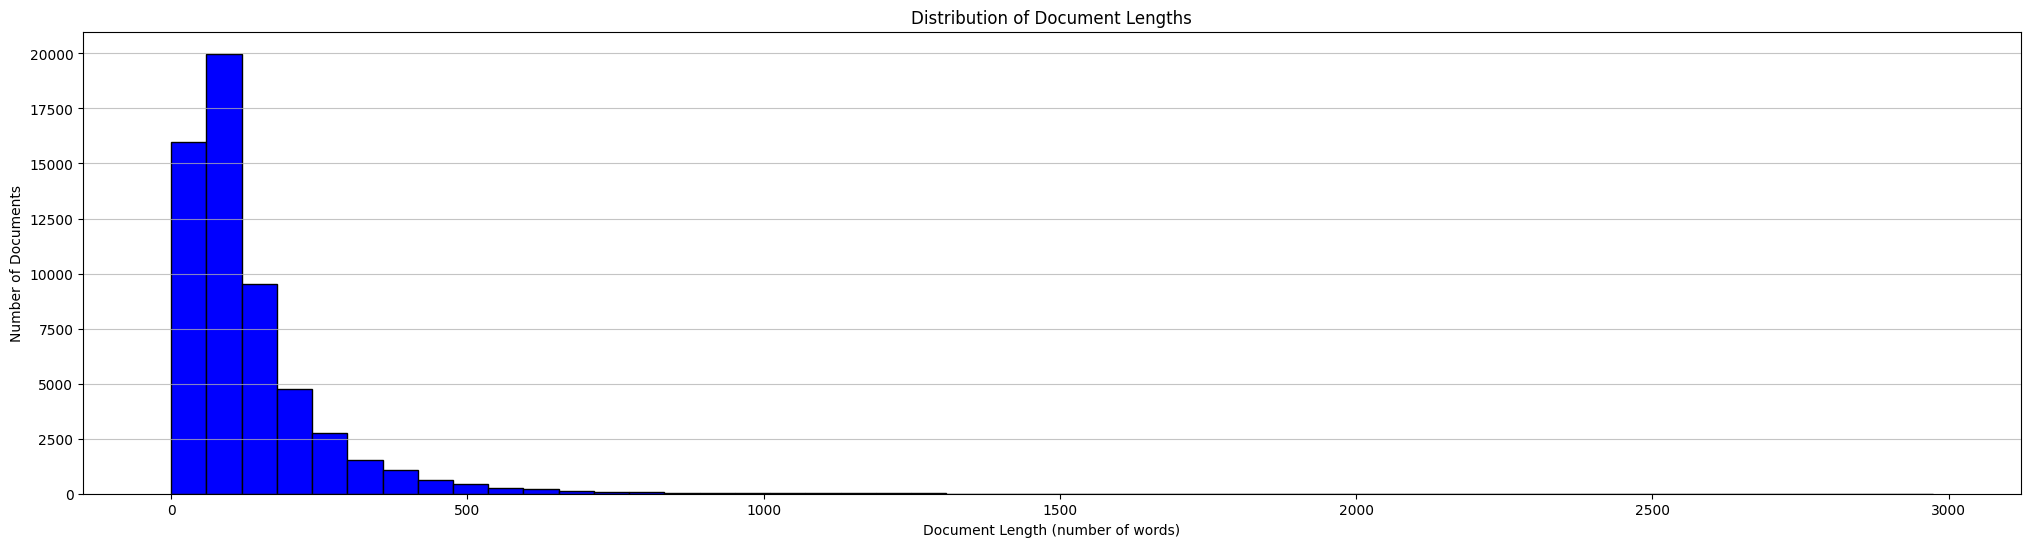

In [ ]:
# Calculate document lengths
document_lengths = df['text'].apply(lambda x: len(str(x).split()))

# Plotting the histogram
plt.figure(figsize=(25, 6))
plt.hist(document_lengths, bins=50, color='blue', edgecolor='black')
plt.title('Distribution of Document Lengths')
plt.xlabel('Document Length (number of words)')
plt.ylabel('Number of Documents')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# How documets that are shorter than 5 words look like - many empty ones
short_docs = df[df['text'].apply(lambda x: len(str(x).split())) < 5]
display(short_docs)

,text,docno
741,,7915
1158,,12229
1329,,14135
3208,,33445
3937,,40982
...,...,...
54963,,572451
55335,"StackExchange points, obviously. =)",576182
55553,A couple of points.,578462
56460,,587667


In [ ]:
# Two of the short documents are relevant to some query, basically impossible to deduct that they are relevant
relevant_short_docs = short_docs[short_docs['docno'].isin(qrels['docno'])]
display(relevant_short_docs)

,text,docno
9908,"Yes, that's correct.",102243
11407,,117276


In [ ]:
# Find all the queries which have more than one relevant doc
(qrels.groupby(['qid']).count()['docno'] >1).sum()

np.int64(428)

In [ ]:
# Those queries are
groupped = qrels.groupby(['qid']).count()
groupped[groupped['docno'] >1]

,docno,label,iteration
qid,,,
10034,2,2,2
10109,7,7,7
10122,4,4,4
10136,3,3,3
10183,2,2,2
...,...,...,...
9871,4,4,4
988,2,2,2
9925,2,2,2


Overall Statistics
count    648.000000
mean       2.632716
std        2.062616
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: docno, dtype: float64


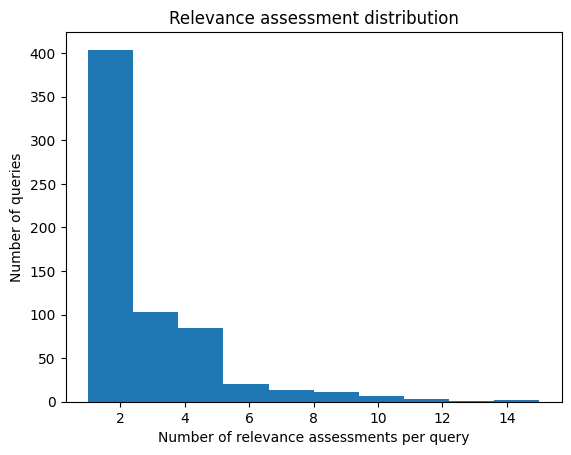

In [ ]:
# Count how many relevance assessments each query has
counts = qrels.groupby("qid")["docno"].count()  # group by query id and count documents
print("Overall Statistics")
print(counts.describe())

# Plot how many relevance assessments each query received
plt.figure()
counts.plot(kind="hist")  # histogram showing distribution of judgment counts
plt.xlabel("Number of relevance assessments per query")
plt.ylabel("Number of queries")
plt.title("Relevance assessment distribution")
plt.show()

Here we want to check how many questions include words expressing polarity of the form "positive" or "negative". This is to check if it makes sense to create a "sentiment polarity filter".

In [ ]:
extended_sentiment_patterns = [
    'positive', 'negative', 'good', 'bad', 'great', 'poor', 'excellent', 'terrible', 'best', 'worst',
    'not', 'no', 'never', "don't", "can't",
    'better', 'worse', 'more efficient', 'less risky',
    'hard', 'difficult', 'easy', 'simple',
    'risky', 'volatile', 'safe', 'secure'
]

# Filter queries for extended sentiment patterns (case-insensitive)
extended_sentiment_queries = queries[queries['query'].str.contains(
    '|'.join(extended_sentiment_patterns), case=False, na=False
)]

num_extended_sentiment_queries = len(extended_sentiment_queries)

print(f"Number of queries containing extended sentiment-related patterns: {num_extended_sentiment_queries}")

if num_extended_sentiment_queries > 0:
    print("Here are some examples of such queries:")
    display(extended_sentiment_queries.head(10))
else:
    print("No queries found containing the specified extended sentiment-related patterns.")

Number of queries containing extended sentiment-related patterns: 111
Here are some examples of such queries:


,qid,query
4,10152,What does a high operating margin but a small but positive ROE imply about a company?
9,6715,What does it mean if “IPOs - normally are sold with an `underwriting discount` (a built in commission)”
10,2388,Do financial advisors get better deals on mortgages?
14,5951,Why can't house prices be out of tune with salaries
19,9332,What can I do with a physical stock certificate for a now-mutual company?
25,7279,"If I invest in securities denominated in a foreign currency, should I hedge my currency risk?"
40,5981,Is it a good investment for a foreigner to purchase a flat/apartment in China?
47,3405,Non Resident aliens - Question of standard vs itemized
70,5422,"What are some good books for learning stocks, bonds, derivatives e.t.c for beginner with a math background?"
77,4600,"Why government bonds fluctuate so much, even though interest rates don't change that often?"


In [ ]:
# Check for Emojis
# A broad regex to catch many common emojis
emoji_pattern = re.compile(
    "["  # Start character class
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags (iOS)
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"
    "]+"
)

emoji_docs = df[df['text'].str.contains(emoji_pattern, na=False)]
num_emoji_docs = len(emoji_docs)

print(f"\nNumber of documents containing emojis: {num_emoji_docs}")
if num_emoji_docs > 0:
    print("Examples of documents with emojis:")
    display(emoji_docs.head())
else:
    print("No documents found containing emojis.")

# Check for Non-Standard Money Quantities (e.g., 5k, 10M)
# Matches a number followed by 'k', 'K', 'm', 'M', 'b', 'B' (for thousands, millions, billions)
money_k_m_pattern = re.compile(r'\b\d+\.?\d*[kKmMBb]\b', re.IGNORECASE)

money_docs = df[df['text'].str.contains(money_k_m_pattern, na=False)]
num_money_docs = len(money_docs)

print(f"\nNumber of documents containing non-standard money quantities (e.g., 5k, 10M): {num_money_docs}")
if num_money_docs > 0:
    print("Examples of documents with non-standard money quantities:")
    display(money_docs.head())
else:
    print("No documents found containing non-standard money quantities.")

# Check for Mentions/Tags (e.g., @user, #hashtag)
# Matches words starting with '@' or '#'
mention_tag_pattern = re.compile(r'[@#]\w+')

mention_tag_docs = df[df['text'].str.contains(mention_tag_pattern, na=False)]
num_mention_tag_docs = len(mention_tag_docs)

print(f"\nNumber of documents containing mentions or hashtags: {num_mention_tag_docs}")
if num_mention_tag_docs > 0:
    print("Examples of documents with mentions or hashtags:")
    display(mention_tag_docs.head())
else:
    print("No documents found containing mentions or hashtags.")


Number of documents containing emojis: 49
Examples of documents with emojis:


text  \
280                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     


Number of documents containing non-standard money quantities (e.g., 5k, 10M): 3747
Examples of documents with non-standard money quantities:


,text,docno
18,"My super fund and I would say many other funds give you one free switch of strategies per year. Some suggest you should change from high growth option to a more balance option once you are say about 10 to 15 years from retirement, and then change to a more capital guaranteed option a few years from retirement. This is a more passive approach and has benefits as well as disadvantages. The benefit is that there is not much work involved, you just change your investment option based on your life stage, 2 to 3 times during your lifetime. This allows you to take more risk when you are young to aim for higher returns, take a balanced approach with moderate risk and returns during the middle part of your working life, and take less risk with lower returns (above inflation) during the latter part of your working life. A possible disadvantage of this strategy is you may be in the higher risk/ higher growth option during a market correction and then change to a more balanced option just when the market starts to pick up again. So your funds will be hit with large losses whilst the market is in retreat and just when things look to be getting better you change to a more balanced portfolio and miss out on the big gains. A second more active approach would be to track the market and change investment option as the market changes. One approach which shouldn't take much time is to track the index such as the ASX200 (if you investment option is mainly invested in the Australian stock market) with a 200 day Simple Moving Average (SMA). The concept is that if the index crosses above the 200 day SMA the market is bullish and if it crosses below it is bearish. See the chart below: This strategy will work well when the market is trending up or down but not very well when the market is going sideways, as you will be changing from aggressive to balanced and back too often. Possibly a more appropriate option would be a combination of the two. Use the first passive approach to change investment option from aggressive to balanced to capital guaranteed with your life stages, however use the second active approach to time the change. For example, if you were say in your late 40s now and were looking to change from aggressive to balanced in the near future, you could wait until the ASX200 crosses below the 200 day SMA before making the change. This way you could capture the majority of the uptrend (which could go on for years) before changing from the high growth/aggressive option to the balanced option. If you where after more control over your superannuation assets another option open to you is to start a SMSF, however I would recommend having at least $300K to $400K in assets before starting a SMSF, or else the annual costs would be too high as a percentage of your total super assets.",277
29,"First, to answer the question. The benefit of a 401k is that you don't have to pay income tax on the money contributed nor do you pay capital gains tax on the money that accumulates. You get that with the restriction that you can't willy nilly remove and contribute money to the account (and you are taxed on withdrawals, more severely if you do it before you are 65). Similar sorts of restrictions apply to all retirement accounts which give tax benefits. Now, for the 7000 not providing benefit. Assuming a very modest 4% growth, over 40 years 7000 becomes 34,671. Not something to sneeze at (inflation, risk reward, blah, blah, blah, it is less than it looks, but 4% is really pretty low, the stock market averages anywhere from 7-&gt;10% and IIRC the bond market is somewhere around 5%). Now, certainly, to avoid bankruptcy you should withdraw. However, if it is possible, you will be best served by keeping the money in your 401k account. The penalties and lost earning opportunities are pretty significant. /u/BeatArmy99 [has the numbers](http://www.reddit.com/r/finance/comments/2ct0qy/why_cant_i_access_my_401k_if_its_my_money/cjiorl7) for how much you lose 


Number of documents containing mentions or hashtags: 1834
Examples of documents with mentions or hashtags:


,text,docno
38,"Hmmmm, 1 or 2, yeah, maybe they were not a good fit for one reason or another. but 5?? Really, you gotta start thinking that maybe, just maybe, there's a chance that's Trump's the problem. #justsayin' is all.",462
52,"""This is the best tl;dr I could make, [original](https://www.richmondfed.org/publications/research/econ_focus/2016/q3-4/profession) reduced by 88%. (I'm a bot) ***** &gt; A 2014 working paper by several German and Swiss researchers, &amp;quot;Happiness of Economists,&amp;quot; concluded on the basis of a large-scale survey that economists are &amp;quot;Highly happy with life&amp;quot;; moreover, those in North America are the happiest. &gt; If working as an economist is so much fun, why do they retire at all? Although mandatory retirement at age 70 was once nearly universal in universities, where most research economists are employed, Congress abolished mandatory retirement for faculty starting in 1994. &gt; Even if a retired economist no longer participates in the profession in any form - no research, no writing, no consulting, no advising students - he or she may well continue to be an economist. ***** [**Extended Summary**](http://np.reddit.com/r/autotldr/comments/6zjx0h/do_economists_ever_really_retire/) | [FAQ](http://np.reddit.com/r/autotldr/comments/31b9fm/faq_autotldr_bot/ """"Version 1.65, ~208272 tl;drs so far."""") | [Feedback](http://np.reddit.com/message/compose?to=%23autotldr """"PM's and comments are monitored, constructive feedback is welcome."""") | *Top* *keywords*: **economist**^#1 **retirement**^#2 **retire**^#3 **economic**^#4 **work**^#5""",643
146,"If I buy VUSA from one exchange, can I sell it in a different exchange, assuming my brokerage account lets me trade in both exchanges? Or is it somehow tied to the exchange I bought it from? This doesn't happen for all securities and between all stock exchanges. So that is dependent on broker and country. I checked for VUSA with Selftrade. They categorically refused allowing me to trade in VUSA in different exchanges. I can only buy and sell in same currency only, albeit sell(buy) in the same exchange where I buy(sell) from. Should be the same behaviour for all brokers for us mere mortals, if you are a bank or a millionaire than that might be a different question. The VUSA you quote is quoted in GBP in LSE and in EUR in AEX, and the ETF has been created by an Irish entity and has an Irish ISIN. As Chris mentioned below, happens between US and Canadian exchanges, but not sure it happens across all exchanges. You cannot deal in inter-listed stocks in LSE and NYSE. Since it's the same asset, its value should not vary across exchanges once you compensate for exchange rates, right? Yes, else it opens up itself for arbitrage (profit without any risk) which everybody wants. So even if any such instance occurs, either people will exploit it to make the arbitrage profit zero (security reflects the equilibrium price) or the profit from such transaction is so less, compared with the effort involved, that people will tend to ignore it. Anyways arbitrage profit is very difficult to garner nowadays, considering the super computers at work in the market who exploit these discrepancies, the moment they see them and bring the security right to the zero arbitrage profit point. If there's no currency risk because of #2, what other factors should I consider when choosing an exchange to trade in? Liquidity? Something else? Time difference, by the time you wake up to trade in Japan, the Japanese markets would have closed. Tax implications across multiple continents. Law of the land, providing protection to investors. Finding a broker dealing in markets you want to explore or dealing with multiple brokers. Regulatory headaches.",1577
159,"""One of the very best case studies of the dangers of sacrificing product quality for profit, [Schlitz Brewing Company](http://en.wikipedia.org/wiki/Joseph_Schlitz_Brewing_Company) was [on the fortune 500 at one time]

In [ ]:
# Regex pattern to find common URL structures (http, https, www, or ending with common domains)
link_pattern = re.compile(r'\b(?:https?://|www\.)\S+\b|\b\S+\.(?:com|org|net|gov|edu|io|co|ai)\b', re.IGNORECASE)

links_docs = df[df['text'].str.contains(link_pattern, na=False)]
num_links_docs = len(links_docs)

print(f"\nNumber of documents containing links: {num_links_docs}")
if num_links_docs > 0:
    print("Examples of documents with links:")
    display(links_docs.head())
else:
    print("No documents found containing links.")


Number of documents containing links: 5946
Examples of documents with links:


,text,docno
7,"This month when you join Scentsy you get a free defuser with your kit! This has never been done before. You also get spring / summer and Fall / Winter testers plus all your kit items! Be your own boss! You choose what hours you work, when and where you work them. Join my Scentsy family today! [Amanda C. Robar Scentsy Business ](http://www.amandacrobar.scentsy.ca)",125
14,"""I read the post. I read what **they said** about it. Yet, that part makes **no sense**. They keep talking about """"only avilable to members of the Florida Bar"""" but stop and think about how that doesn't make sense. Are they in a *florida* court or in a *federal* court? Or an IP/administrative setting? Some things they wrote suggests they're in a *federal* court. But others things suggest they're in an administrative court related to IP. For example, they talk about needing an attorney who can represent them in the Trademark/IP courts. That sounds like patent prosecution - but that's typically just about getting the patent/IP stuff in the first place - and not so much after-the-fact stuff. But then again, I'm not at all familiar with the area so I could be way off base. The problem is: I shouldn't have to be speculating so much because their story sucked. But patent litigation (for infringement for example) as far as I was aware, occurs in traditional district courts and so far as I am aware you don't need a special trademark/ip exam to sue on it. By contrast, patent *prosecution*, which is getting a patent through the offices, requires that the attorney take the USPTO exam - to become a 'patent' attorney. [link](http://en.wikipedia.org/wiki/USPTO_registration_examination). Federal courts, if that's where they are, typically use PACER ECF/CM (case management web portal). Which, I'll have to assume is the system they are referring to. https://www.pacer.gov/psco/cgi-bin/regform.pl That's where anyone can fucking sign up for it. Then they can look at dockets and all that jazz. Maybe there's another system I'm not familiar with OR another system that I can't discern from the way they wrote the story. But so far. More BS or just confusing or wrong information. This is why they should have hired a lawyer.""",222
29,"First, to answer the question. The benefit of a 401k is that you don't have to pay income tax on the money contributed nor do you pay capital gains tax on the money that accumulates. You get that with the restriction that you can't willy nilly remove and contribute money to the account (and you are taxed on withdrawals, more severely if you do it before you are 65). Similar sorts of restrictions apply to all retirement accounts which give tax benefits. Now, for the 7000 not providing benefit. Assuming a very modest 4% growth, over 40 years 7000 becomes 34,671. Not something to sneeze at (inflation, risk reward, blah, blah, blah, it is less than it looks, but 4% is really pretty low, the stock market averages anywhere from 7-&gt;10% and IIRC the bond market is somewhere around 5%). Now, certainly, to avoid bankruptcy you should withdraw. However, if it is possible, you will be best served by keeping the money in your 401k account. The penalties and lost earning opportunities are pretty significant. /u/BeatArmy99 [has the numbers](http://www.reddit.com/r/finance/comments/2ct0qy/why_cant_i_access_my_401k_if_its_my_money/cjiorl7) for how much you lose by doing an early withdraw. Don't do this lightly and I would suggest avoiding cashing out the whole thing if you can.",396
30,"""the truth from the 'horse mouth"""" - and no he's NOT alt-right, as he's painted by political interests from all sides.... Well, updates and flashnews: 1. Google pontificating on diversity and women's equality: Sergei Brin divorced after cheating on his high achieving brilliant wife with a junior staffer. Guess who left the company after it was found out? 2. Eric Schmidt - rumour has it he likes to """"party"""" - a lot! Good that Google """"leadership"""" is keep

In [ ]:
# Regex to find text within single or double quotes
# It tries to be smart about nested quotes by not being too greedy with the closing quote.
# This pattern looks for a quote, then any character (non-greedy) until another quote.
quoted_text_pattern = re.compile(r'["\\](.+?)["\\]')

extended_quoted_docs = []

for index, row in df.iterrows():
    doc_text = row['text']
    matches = quoted_text_pattern.findall(doc_text)

    found_extended_quote = False
    for quote in matches:
        # Simple word count by splitting on whitespace
        if len(quote.split()) > 5:
            extended_quoted_docs.append({"docno": row['docno'], "text": doc_text, "extended_quote": quote})
            found_extended_quote = True
            break # Only need one extended quote per doc to count it

num_extended_quoted_docs = len(extended_quoted_docs)

print(f"\nNumber of documents containing extended quoted text (more than 5 words): {num_extended_quoted_docs}")

if num_extended_quoted_docs > 0:
    print("\nExamples of documents with extended quoted text:")
    # Convert to DataFrame for pretty display
    display(pd.DataFrame(extended_quoted_docs).head(2))
else:
    print("No documents found containing extended quoted text.")


Number of documents containing extended quoted text (more than 5 words): 14386

Examples of documents with extended quoted text:


,docno,text,extended_quote
0,100,"""Only relevant to those with fantasy economy teams. Seriously, Rand's fictional works never translate well into reality because, no matter how hard people try, that """"fiction"""" element just can't be ignored. Test it yourself: Strip John Galt and his followers of everything they have which was created by or within the """"society"""" they so revile, drop them in the desert -- and they'll all be dead of exposure and starvation in less than two weeks because they will be naked, without tools and without food. The only reason the libertarians get away with pushing their tripe as a rational philosophy is because no one will point out what it is wrong with their thinking. Why? Well, for most of my lifetime, their """"philosophy"""" was considered nuttery in line with the John Birchers and so why bother. It's only with the ascendency of these billionaire-funded politicians that this crap thinking has become acceptable, and even then, only to them.""","Only relevant to those with fantasy economy teams. Seriously, Rand's fictional works never translate well into reality because, no matter how hard people try, that"
1,178,"""At any given moment, one can tally the numbers used for NAV. It's math, and little more. The Market Cap, which as you understand is a result of share value. Share value (stock price) is what the market will pay today for the shares. It's not only based on NAV today, but on future expectations. And expectations aren't the same for each of us. Which is why there are always sellers for the buyers of a stock, and vice-versa. From your question, we agree that NAV can be measured, it's the result of adding up things that are all known. (For now, let's ignore things such as """"goodwill."""") Rarely is a stock price simply equal to the NAV divided by the number of shares. Often, it's quite higher. The simplest way to look at it is that the stock price not only reflects the NAV, but investors' expectations looking into the future. If you look for two companies with identical NAV per share but quite different share prices, you'll see that the companies differ in that one might be a high growth company, the other, a solid one but with a market that's not in such a growth mode.""","At any given moment, one can tally the numbers used for NAV. It's math, and little more. The Market Cap, which as you understand is a result of share value. Share value (stock price) is what the market will pay today for the shares. It's not only based on NAV today, but on future expectations. And expectations aren't the same for each of us. Which is why there are always sellers for the buyers of a stock, and vice-versa. From your question, we agree that NAV can be measured, it's the result of adding up things that are all known. (For now, let's ignore things such as"


### Exploration with Qrels

Let's find the number of words that overlap in each query-doc couple (words not in stop words)

In [ ]:
stop_words = set(stopwords.words('english'))

def calculate_common_words(qrels_df, queries_df, docs_df, stop_words_set, query_text_column='query'):
  copy_qrels = qrels_df.copy()
  copy_qrels['common_word_count'] = 0
  copy_qrels['common_word'] = ''

  for index, row_data in qrels_df.iterrows():
    # Use the specified query_text_column
    q_text_series = queries_df[queries_df['qid'].astype(str) == str(row_data['qid'])][query_text_column]
    q_doc_series = docs_df[docs_df['docno'] == row_data['docno']]['text']

    if not q_text_series.empty and not q_doc_series.empty:
        q_text_words = set(q_text_series.iloc[0].lower().split())
        q_doc_words = set(q_doc_series.iloc[0].lower().split())
        words = q_text_words.intersection(q_doc_words)
        words = {w for w in words if w not in stop_words_set}
        common = len(words)
    else:
        common = 0
        words = set()

    copy_qrels.loc[index, 'common_word_count'] = common
    copy_qrels.loc[index, 'common_word']= ', '.join(list(words))
  return copy_qrels

# Average number of shared words in query doc couples
copy_qrels = calculate_common_words(qrels, queries, df, stop_words, query_text_column='query')
avg = copy_qrels['common_word_count'].mean()
print(f"On average relevant doc-queries couples have {avg:.3f} matching words")

On average relevant doc-queries couples have 1.715 matching words


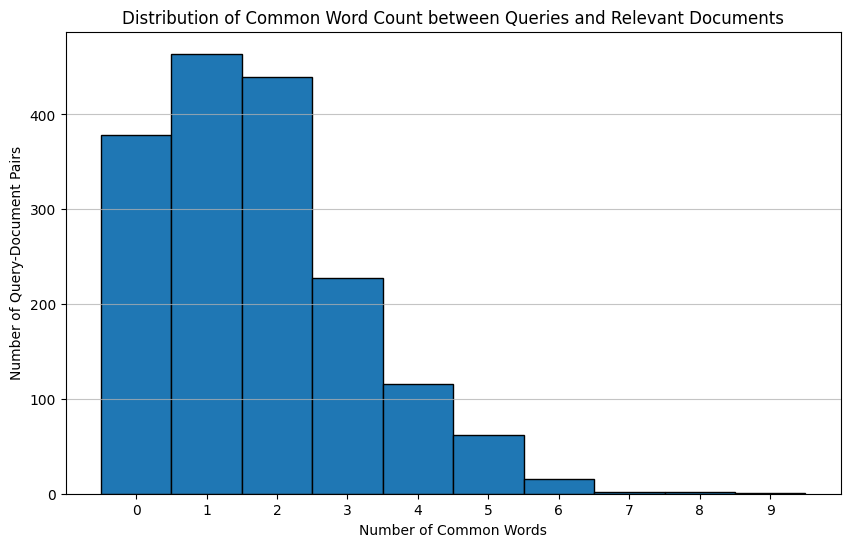

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(copy_qrels['common_word_count'], bins=range(int(copy_qrels['common_word_count'].max()) + 2), edgecolor='black', align='left')
plt.title('Distribution of Common Word Count between Queries and Relevant Documents')
plt.xlabel('Number of Common Words')
plt.ylabel('Number of Query-Document Pairs')
plt.xticks(range(int(copy_qrels['common_word_count'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# check how many query-doc pairs don't have common words
print(f"Query-doc pairs with zero matching words: {copy_qrels[copy_qrels['common_word_count'] == 0].shape[0]}")

Query-doc pairs with zero matching words: 378


Given this last result we suppose that the statistical count methods might have some difficulties in matching the documents with the queries.

# Basic experiments

## Experiment 1

Indexing

In [ ]:
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)
index_ref = indexer.index(df.to_dict(orient="records"))

# Open the index to ensure it is valid
index = pt.IndexFactory.of(index_ref)

print("Index location:", index_path)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


Java started (triggered by TerrierIndexer.__init__) and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


15:17:51.337 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
15:18:10.672 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents
Index location: ./terrier_index
Indexed documents: 57638


In [ ]:
# Retrieve collection statistics
stats = index.getCollectionStatistics()

print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

Terrier Collection Statistics
--------------------------------
Indexed documents:        57638
Unique terms (vocabulary): 74781
Total tokens:             7988905
Average document length:  138.60


###Test 1


*   Lowercase docs and remove non-aphabetical symbols (keep numbers)
*   Apply BM25, PL2, TF-IDF



In [ ]:
# Replace colons with spaces in the query column
queries_cleaned = queries.copy()
queries_cleaned['query'] = queries['query'].str.replace(':', ' ', regex=False)

# We might also want to remove other reserved TerrierQL characters
# like +, -, ^, etc., if they appear in your data purely as text.
# A regex to remove non-alphanumeric chars (keeping spaces):
queries_cleaned['query'] = queries['query'].str.replace(r'[^a-zA-Z0-9 ]', ' ', regex=True)

queries_cleaned['query'] = queries_cleaned['query'].str.lower()

In [ ]:
# Apply BM25, PL2 and TF-IDF algorithms
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_pl2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))
retrieval_pipeline_tfidf = (pt.terrier.Retriever(index_ref, wmodel="TF_IDF"))

metrics_to_evaluate = [
    'P.1', 'P.5', 'P.10',
    'recall.5', 'recall.10',
    'ndcg_cut_5', 'ndcg_cut_10',
    'map'
]

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25, retrieval_pipeline_pl2, retrieval_pipeline_tfidf],
    queries_cleaned, # Use the cleaned and lowercased queries here
    qrels,
    names=["BM25", "PL2", "TF_IDF"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.169979,0.188272,0.088889,0.056636,0.211480,0.264339,0.190401,0.208399
1,PL2,0.172645,0.194444,0.093519,0.061265,0.217566,0.276153,0.195496,0.215132
2,TF_IDF,0.189185,0.220679,0.099383,0.064660,0.228473,0.290529,0.212005,0.233018


###Test 2


* Lowercase docs and keeping non-aphabetical symbols
* Apply BM25, PL2, TF-IDF



In [ ]:
# Replace colons with spaces in the query column
queries_cleaned = queries.copy()
queries_cleaned['query'] = queries['query'].str.replace(':', ' ', regex=False)

queries_cleaned['query'] = queries_cleaned['query'].str.lower()

In [ ]:
# Apply BM25, PL2 and TF-IDF algorithms
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_pl2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))
retrieval_pipeline_tfidf = (pt.terrier.Retriever(index_ref, wmodel="TF_IDF"))

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25, retrieval_pipeline_pl2, retrieval_pipeline_tfidf],
    queries_cleaned, # Use the cleaned and lowercased queries (keeping non-alphanumeric chars)
    qrels,
    names=["BM25", "PL2", "TF_IDF"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.169979,0.188272,0.088889,0.056636,0.211480,0.264339,0.190401,0.208399
1,PL2,0.172645,0.194444,0.093519,0.061265,0.217566,0.276153,0.195496,0.215132
2,TF_IDF,0.189185,0.220679,0.099383,0.064660,0.228473,0.290529,0.212005,0.233018


As we can see, keeping the non-alphabetical symbols didn't change the score.

###Test 3
* Doing query expansion on lowercased docs keeping non-aphabetical symbols and then apply again BM25 /PL2 / TF-IDF

In [ ]:
# Apply BM25 and RM3
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_rm3_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="BM25")
)

# Apply PL2 and RM3
retrieval_pipeline_pl2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))
retrieval_pipeline_rm3_pl2 = (pt.terrier.Retriever(index_ref, wmodel="PL2") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="PL2")
)

# Apply TF-IDF and RM3
retrieval_pipeline_tfidf = (pt.terrier.Retriever(index_ref, wmodel="TF_IDF"))
retrieval_pipeline_rm3_tfidf = (pt.terrier.Retriever(index_ref, wmodel="TF_IDF") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="TF_IDF")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25, retrieval_pipeline_rm3_bm25, retrieval_pipeline_pl2, retrieval_pipeline_rm3_pl2, retrieval_pipeline_tfidf, retrieval_pipeline_rm3_tfidf],
    queries_cleaned, # Use the cleaned and lowercased queries (keeping non-alphanumeric chars)
    qrels,
    names=["BM25", "BM25+RM3", "PL2", "PL2+RM3", "TF_IDF", "TF_IDF+RM3"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.169979,0.188272,0.088889,0.056636,0.211480,0.264339,0.190401,0.208399
1,BM25+RM3,0.163526,0.177469,0.084259,0.056173,0.199162,0.257393,0.177735,0.198625
2,PL2,0.172645,0.194444,0.093519,0.061265,0.217566,0.276153,0.195496,0.215132
3,PL2+RM3,0.165254,0.183642,0.085802,0.057562,0.192830,0.256627,0.179097,0.201280
4,TF_IDF,0.189185,0.220679,0.099383,0.064660,0.228473,0.290529,0.212005,0.233018
5,TF_IDF+RM3,0.182664,0.208333,0.092284,0.062809,0.210789,0.282899,0.197898,0.223387


Doing query expansion didn't increase the score, on contrary, it dropped a little.

## Experiment 2

### Test 1


*   Keep unpreprocessed docs
*   Expand the query syntatically (add synonyms of relevant words)
*   Keep only english alphabetical symbols and numbers




Functions implemented:

*   `Extracts meaningful terms` : extracts lemmatized nouns and noun chunks from a given text.

*   `get_recursive_definitions` : fetches definition for a word from WordNet
*   `calculate_common_words` : computes common number of common words between queries and docs


In [11]:
# Load spaCy model
nlp = spacy.load('en_core_web_sm')

def extract_meaningful_terms(text):
    """
    Extracts meaningful terms (lemmatized nouns and noun chunks) from a given text.
    Uses spaCy for linguistic analysis and filters out stopwords.
    """
    doc = nlp(text)
    terms = set()
    # Add noun chunks
    for chunk in doc.noun_chunks:
        cleaned_chunk = " ".join([token.lemma_.lower() for token in chunk if token.lemma_.lower() not in STOP_WORDS])
        if cleaned_chunk:
            terms.add(cleaned_chunk)
    # Add individual nouns (lemmatized and non-stopwords)
    for token in doc:
        if token.pos_ == "NOUN" and token.lemma_.lower() not in STOP_WORDS:
            terms.add(token.lemma_.lower())
    return list(terms)

def get_recursive_definitions(word, max_depth=0, current_depth=0, visited_definitions=None):
    """
    Recursively fetches definitions for a word and then for terms found within those definitions.

    Args:
        word (str): The word to get definitions for.
        max_depth (int): The maximum depth of recursion (e.g., 0 for just the word,
                         1 for definitions of the word and terms in those definitions).
        current_depth (int): The current depth of recursion.
        visited_definitions (set): A set to keep track of definitions already processed
                                   to prevent infinite loops and redundant output.
    Returns:
        set: A set of unique keywords extracted from the definitions up to the specified depth.
    """
    if visited_definitions is None:
        visited_definitions = set()

    if current_depth > max_depth:
        return set() # Return an empty set if max_depth is exceeded

    synsets = wn.synsets(word)
    if not synsets:
        return set() # Return empty if no synsets

    all_keywords_for_this_call = set()

    for synset in synsets[:3]:
        definition = synset.definition()
        if definition not in visited_definitions:
            visited_definitions.add(definition)

            terms_in_definition = extract_meaningful_terms(definition)
            # Filter out the original word itself to avoid trivial recursion
            terms_in_definition = [t for t in terms_in_definition if t != word.lower() and len(t) > 2]

            if terms_in_definition:
                all_keywords_for_this_call.update(terms_in_definition)

            if current_depth < max_depth:
                if terms_in_definition:
                    for term in terms_in_definition:
                        # Recursively get keywords and merge them
                        all_keywords_for_this_call.update(get_recursive_definitions(term, max_depth, current_depth + 1, visited_definitions))

    return sorted(list(all_keywords_for_this_call))

# Example usage:
word_to_explore = 'fund'
all_found_keywords = get_recursive_definitions(word_to_explore, max_depth=0)
print(f"All keywords from definitions of '{word_to_explore}':")
print(all_found_keywords)


All keywords from definitions of 'fund':
['company', 'financial institution', 'future use', 'individual', 'institution', 'invest', 'money', 'purpose', 'reserve', 'security', 'share', 'supply', 'use']


Since using the full definition of each keyword would make the expansion too long we get the key words of the definitions and just append them to the queries.
Thus the following cells implement:

*   get keywords from queries
*   look up their definitions
*   add the keywords of the definitions to the queries

In [12]:
# To avoid messing up with the queries df create a copy
augmented_q = queries.copy()
augmented_q['aug_query'] = ''

for index, row_data in augmented_q.iterrows():
  original_query_text = row_data['query'] # Get the query text directly from the current row
  query_keywords = extract_meaningful_terms(original_query_text) # Pass original text

  all_augmented_keywords_for_query = set() # Use a set to collect all unique keywords for the current query

  for term in query_keywords:
    keywords_from_term_definition = get_recursive_definitions(term, max_depth=0) # Get keywords from the definition of the current term
    all_augmented_keywords_for_query.update(keywords_from_term_definition) # Add to the collective set

  # Combine original query text with augmented keywords
  augmented_q.loc[index, 'aug_query'] = original_query_text + ' ' + ', '.join(sorted(list(all_augmented_keywords_for_query)))

augmented_q.head(5)

,qid,query,aug_query
0,4641,Where should I park my rainy-day / emergency fund?,"Where should I park my rainy-day / emergency fund? action, axis, brake, company, complete rotation, crisis, danger, earth, financial institution, future use, hand, immediate action, individual, institution, invest, law, linkage, martial law, mechanical linkage, money, observance, particular purpose, period, point, purpose, rain, reserve, rotation, security, share, state, sudden unforeseen crisis, supply, time, use, weather, wet"
1,5503,Tax considerations for selling a property below appraised value to family?,"Tax considerations for selling a property below appraised value to family? activity, area, attribute, basic essential attribute, careful thought, child, citizen, citizen person, class, collection, common attribute, decision, discussion, equivalent, fair equivalent, fine, good, government, group, information, meeting, member, mind, money, numerical quantity, parent, particular purpose, payment, person, possession, primary social group, process, property, purpose, quality, quantity, service, social unit, support, tangible intangible possession, thing, thought, topic, unit"
2,7803,Can the Delta be used to calculate the option premium given a certain target?,"Can the Delta be used to calculate the option premium given a certain target? 4th letter, act, agree price, aim, alluvial deposit, alphabet, area, attack, body, currency, date, deposit, equilateral triangle, especially victim, exploitation, fee, greek alphabet, hostile person, influence, insurance, large body, letter, location, low triangular area, money, nominal value, number, object, payment, person, point, price, property, reference, reference point, ridicule, right, river, scarce supply, state date, supply, thing, triangle, triangular, value, victim, water"
3,7017,Basic Algorithmic Trading Strategy,"Basic Algorithmic Trading Strategy action, branch, command, conduct, elaborate systematic plan, military command, military science, plan, planning, science, war"
4,10152,What does a high operating margin but a small but positive ROE imply about a company?,"What does a high operating margin but a small but positive ROE imply about a company? area, boundary, boundary line, broker, business, collateral, control, customer, customer deposit, deposit, institution, line, platoon, project, security, small military unit, state, unit, usually platoon"


Check if now the synthatic overlap between the queries and the docs increased. This provides already an hint on the performance of the test we are going to run here. If the overlap don't increase much then we suspect that the performance won't increase either.

In [13]:
def calculate_common_words(qrels_df, queries_df, docs_df, stop_words_set, query_text_column='query'):
  # Create a copy of the qrels DataFrame to avoid modifying the original
  copy_qrels = qrels_df.copy()
  copy_qrels['common_word_count'] = 0
  copy_qrels['common_word'] = ''

  # Iterate through each row in the qrels DataFrame
  for index, row_data in qrels_df.iterrows():
    # Retrieve the query text for the current qid (query ID) from the queries DataFrame
    # The column to use for the query text is specified by `query_text_column`
    q_text_series = queries_df[queries_df['qid'].astype(str) == str(row_data['qid'])][query_text_column]
    # Retrieve the document text for the current docno (document number) from the documents DataFrame
    q_doc_series = docs_df[docs_df['docno'] == row_data['docno']]['text']

    # Check if both the query text and document text were successfully found
    if not q_text_series.empty and not q_doc_series.empty:
        q_text_words = set(q_text_series.iloc[0].lower().split())
        q_doc_words = set(q_doc_series.iloc[0].lower().split())
        # Find the intersection of words between the query and the document
        words = q_text_words.intersection(q_doc_words)
        words = {w for w in words if w not in stop_words_set}
        common = len(words)
    else:
        # If either the query or document could not be found, set common count to 0 and words to an empty set
        common = 0
        words = set()

    copy_qrels.loc[index, 'common_word_count'] = common
    copy_qrels.loc[index, 'common_word']= ', '.join(list(words))
  return copy_qrels

In [14]:
aug_qrels = calculate_common_words(qrels, augmented_q, df, stop_words,  query_text_column='aug_query')
aug_qrels.head()

,qid,docno,label,iteration,common_word_count,common_word
0,8,566392,1,0,0,
1,8,65404,1,0,4,"cheque, write, deposit, associate"
2,15,325273,1,0,3,"mail, money, order"
3,18,88124,1,0,1,ein
4,26,285255,1,0,4,"financial, business, credit, income"


In [15]:
# Average number of shared words in query doc couples
aug_qrels = calculate_common_words(qrels, augmented_q, df, stop_words,  query_text_column='aug_query')
aug_qrels.head()

,qid,docno,label,iteration,common_word_count,common_word
0,8,566392,1,0,0,
1,8,65404,1,0,4,"cheque, write, deposit, associate"
2,15,325273,1,0,3,"mail, money, order"
3,18,88124,1,0,1,ein
4,26,285255,1,0,4,"financial, business, credit, income"


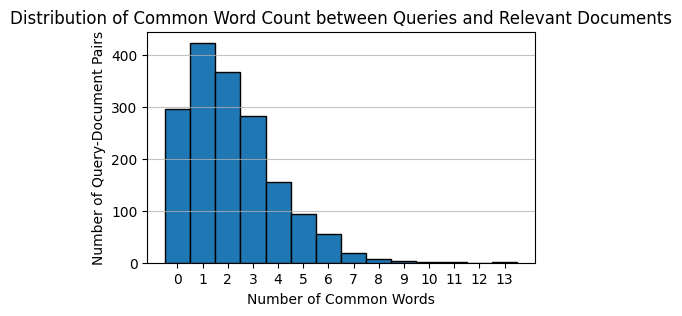

In [16]:
plt.figure(figsize=(5, 3))
plt.hist(aug_qrels['common_word_count'], bins=range(int(aug_qrels['common_word_count'].max()) + 2), edgecolor='black', align='left')
plt.title('Distribution of Common Word Count between Queries and Relevant Documents')
plt.xlabel('Number of Common Words')
plt.ylabel('Number of Query-Document Pairs')
plt.xticks(range(int(aug_qrels['common_word_count'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

Queries and relevant documents, have mostly one common word, this means that this kind of preprocessing might actually not be that useful.
Let's check this intuition running the test.


In [17]:
# Index the raw collection
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)

#to use the IterDictIndexer with a dataframe we have to use the .to_dict() function
index_ref = indexer.index(df.to_dict(orient="records"))

# Open the index to ensure it is valid
index = pt.IndexFactory.of(index_ref)

print("Index location:", index_path)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


Java started (triggered by TerrierIndexer.__init__) and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


19:25:08.130 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
19:25:28.309 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents
Index location: ./terrier_index
Indexed documents: 57638


In [18]:
# Replace colons with spaces in the query column
aug_queries_cleaned = augmented_q.copy()
aug_queries_cleaned['query'] = augmented_q['aug_query'].str.replace(':', ' ', regex=False)

# like +, -, ^, etc., if they appear in your data purely as text.
# A regex to remove non-alphanumeric chars (keeping spaces):
aug_queries_cleaned['query'] = aug_queries_cleaned['query'].str.replace(r'[^a-zA-Z0-9 ]', ' ', regex=True)

In [21]:
aug_queries_cleaned['query'] = aug_queries_cleaned['query'].str.lower()

retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_PL2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="BM25")
)

retrieval_pipeline_pl2rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="PL2")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3, retrieval_pipeline_PL2, retrieval_pipeline_pl2rm3],
    aug_queries_cleaned,
    qrels,
    names=["BM25","BM25+RM3", "PL2", "BM25+RM3+PL2"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.056306,0.054012,0.027778,0.019907,0.065133,0.090237,0.057040,0.066037
1,BM25+RM3,0.053783,0.054012,0.026235,0.017593,0.061173,0.075883,0.055183,0.060837
2,PL2,0.055813,0.049383,0.029321,0.020988,0.066922,0.093268,0.057922,0.067593
3,BM25+RM3+PL2,0.053264,0.054012,0.027469,0.018364,0.062819,0.079804,0.056015,0.062335


As expected, this kind of query expansion did not yield better results.

### Test 2


*   Keep unpreprocessed docs
*   Expand acronyms
*   Keep only English alphabetical symbols and numbers


Functions implemented:

* `extract_acronyms` : extracts acronyms from any string
*  `filter_known_acronyms` : filters a list of acronyms returning only those found in the glossary
* `get_non_found_acronyms` : returns a list of acronyms foud in a specified corpus but not present in the glossary
* `expand_query_with_acronyms` : given a string and the glossary (as dictionary) returns the same string with the appended expansion

In [22]:
acr_queries = queries.copy()

def extract_acronyms(text):
    pattern = r"\b[A-Z]{2,5}\b"
    locations = defaultdict(list)

    for match in re.finditer(pattern, text):
        locations[match.group()].append(match.start())

    return dict(locations)

acr_queries["acronyms"] = queries["query"].apply(extract_acronyms)
acr_queries.head(5)

,qid,query,acronyms
0,4641,Where should I park my rainy-day / emergency fund?,{}
1,5503,Tax considerations for selling a property below appraised value to family?,{}
2,7803,Can the Delta be used to calculate the option premium given a certain target?,{}
3,7017,Basic Algorithmic Trading Strategy,{}
4,10152,What does a high operating margin but a small but positive ROE imply about a company?,{'ROE': [59]}


In [23]:
# count number of queries which have at least one acronym detected
acr_queries["acronyms"].apply(lambda x: x != {}).sum()

np.int64(116)

Substitute the acronyms with their expansion from the glossary stored on Github

In [24]:
glossary_df = pd.read_excel('GLOSSARY_Budget_Finance_Acronyms_Jan2022.xlsx', engine='openpyxl')
glossary_df = glossary_df.rename(columns={"340B": "Acronym", "340B Drug Pricing Program": "Meaning"}, errors="raise")
glossary_df.head()

,Acronym,Meaning
0,AACSB,The Association to Advance Collegiate Schools of Business
1,AADC,Associate Alumnae of Douglass College
2,AAS,Audit and Advisory Services
3,AAU,Association of American Universities
4,AAUP,American Association of University Professors


In [25]:
# Clean the gloassary meanings to have the expanded in lowercase
glossary_df["Meaning"] = glossary_df["Meaning"].str.lower()
# glossary_df["Meaning"] = glossary_df["Meaning"].str.replace(r"[^a-z\s]", "", regex=True) #CANT DO IT OR HAVE TO DO IT FOR EVERYTHING

In [26]:
# make the glossary as a dictionary for easier handling
acronym2expansion = dict(
    zip(glossary_df["Acronym"], glossary_df["Meaning"])
)
print(acronym2expansion.get("AADC"))

associate alumnae of douglass college


In [27]:
def filter_known_acronyms(acronyms, acronym_dict):
    return [a for a in acronyms if a in acronym_dict]

In [28]:
def get_non_found_acronyms(query, acronym_dict):
    acronyms_in_query = extract_acronyms(query).keys()
    return [a for a in acronyms_in_query if a not in acronym_dict]

In [29]:
def expand_query_with_acronyms(query, acronym_dict):
    acronyms_with_locations = extract_acronyms(query)

    # Collect all replacements as (start, end, replacement_text)
    replacements = []

    for acronym, positions in acronyms_with_locations.items():
        if acronym in acronym_dict:
            expansion = acronym_dict[acronym]
            for pos in positions:
                replacements.append(
                    (pos, pos + len(acronym), f"{acronym} ({expansion})")
                )

    # Sort replacements from right to left to avoid index shifting
    replacements.sort(key=lambda x: x[0], reverse=True)

    expanded_query = query
    for start, end, replacement in replacements:
        expanded_query = (
            expanded_query[:start] + replacement + expanded_query[end:]
        )

    return expanded_query

Since there could be acronyms not present in our glossary, let's get them

In [30]:
all_non_found_acronyms = set()
for query_text in queries['query']:
    non_found_for_query = get_non_found_acronyms(query_text, acronym2expansion)
    all_non_found_acronyms.update(non_found_for_query)

total_unique_non_found_acronyms = len(all_non_found_acronyms)

print(f"Total number of distinct acronyms not found in the glossary: {total_unique_non_found_acronyms}")
print(f"List of unique non-found acronyms: {sorted(list(all_non_found_acronyms))}")

Total number of distinct acronyms not found in the glossary: 65
List of unique non-found acronyms: ['ACH', 'ADR', 'AMT', 'ASX', 'AVS', 'BOTH', 'CBS', 'CD', 'CFD', 'CNN', 'CREF', 'CSV', 'DEBIT', 'DRYS', 'DXJR', 'EI', 'EIN', 'ESPP', 'ETF', 'EU', 'EWU', 'FHA', 'FTB', 'FX', 'GOOG', 'GOOGL', 'HOW', 'HSA', 'HSBC', 'IOPTS', 'IPOA', 'IRA', 'IS', 'ISA', 'JSON', 'MACD', 'MISC', 'MY', 'NR', 'OWN', 'PE', 'PEG', 'ROE', 'RRSP', 'SEC', 'SEIS', 'SEP', 'SMSF', 'SNAP', 'SSA', 'SWIFT', 'TEN', 'TIAA', 'TPP', 'TSP', 'UCITS', 'UK', 'US', 'USA', 'USPS', 'UTMA', 'VAT', 'VISA', 'WHERE', 'XIRR']


Let's manually add the missing acronyms, taking only the ones that have financial significance.
The full name expansion has been generated by chatgpt.

In [31]:
manual_acronym_expansions = {
    "ACH": "automated clearing house",
    "ADR": "american depositary receipt",
    "AMT": "alternative minimum tax",
    "ASX": "australian securities exchange",
    "CD": "certificate of deposit",
    "CFD": "contract for difference",
    "CREF": "college retirement equities fund",
    "DEBIT": "debit card debit payment",
    "EI": "earned income",
    "EIN": "employer identification number",
    "ESPP": "employee stock purchase plan",
    "ETF": "exchange traded fund",
    "EU": "european union",
    "FHA": "federal housing administration",
    "FTB": "first time buyer",
    "FX": "foreign exchange",
    "HSA": "health savings account",
    "HSBC": "hongkong and shanghai banking corporation",
    "IPOA": "initial public offering acquisition",
    "IRA": "individual retirement account",
    "ISA": "individual savings account",
    "MACD": "moving average convergence divergence",
    "PE": "price earnings ratio",
    "PEG": "price earnings growth ratio",
    "ROE": "return on equity",
    "RRSP": "registered retirement savings plan",
    "SEC": "securities and exchange commission",
    "SEIS": "seed enterprise investment scheme",
    "SEP": "simplified employee pension",
    "SMSF": "self managed super fund",
    "SSA": "social security administration",
    "SWIFT": "society for worldwide interbank financial telecommunication",
    "TIAA": "teachers insurance and annuity association",
    "TPP": "third party payment",
    "TSP": "thrift savings plan",
    "UCITS": "undertakings for collective investment in transferable securities",
    "UK": "united kingdom",
    "US": "united states",
    "USA": "united states of america",
    "UTMA": "uniform transfers to minors act",
    "VAT": "value added tax",
    "VISA": "visa payment network",
    "XIRR": "extended internal rate of return"
}

In [32]:
# Update the dictionary with the missing acronyms
acronym2expansion.update(manual_acronym_expansions)

In [33]:
# Returns the original and expanded queries
acr_queries["expanded_query"] = acr_queries["query"].apply(
    lambda q: expand_query_with_acronyms(q, acronym2expansion)
)
display(acr_queries.head(5))

,qid,query,acronyms,expanded_query
0,4641,Where should I park my rainy-day / emergency fund?,{},Where should I park my rainy-day / emergency fund?
1,5503,Tax considerations for selling a property below appraised value to family?,{},Tax considerations for selling a property below appraised value to family?
2,7803,Can the Delta be used to calculate the option premium given a certain target?,{},Can the Delta be used to calculate the option premium given a certain target?
3,7017,Basic Algorithmic Trading Strategy,{},Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small but positive ROE imply about a company?,{'ROE': [59]},What does a high operating margin but a small but positive ROE (return on equity) imply about a company?


Now that we have the expanded queries we can check the performances of the models

In [34]:
index_path_exp = "./exp_terrier_index"
if os.path.exists(index_path_exp):
    shutil.rmtree(index_path_exp)
os.makedirs(index_path_exp, exist_ok=True)

indexer_exp = pt.IterDictIndexer(
    index_path_exp,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)

index_ref_exp = indexer_exp.index(df.to_dict(orient="records"))
index = pt.IndexFactory.of(index_ref_exp)

print("Index location:", index_path_exp)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

19:34:03.425 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
19:34:19.694 [ForkJoinPool-2-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents
Index location: ./exp_terrier_index
Indexed documents: 57638


In [35]:
# Replace colons with spaces in the query column
acr_queries_cleaned = acr_queries.copy()
acr_queries_cleaned['query'] = acr_queries['expanded_query'].str.replace(':', ' ', regex=False)

# A regex to remove non-alphanumeric chars:
# acr_queries_cleaned['query'] = acr_queries['expanded_query'].str.replace(r'[^a-zA-Z0-9 ]', ' ', regex=True) CHECK IF IT IS APPLIED TO EVERYTHING

In [36]:
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref_exp, wmodel="BM25"))
retrieval_pipeline_PL2 = (pt.terrier.Retriever(index_ref_exp, wmodel="PL2"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(index_ref_exp, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref_exp) >>
    pt.terrier.Retriever(index_ref_exp, wmodel="BM25")
)

retrieval_pipeline_pl2rm3 = (pt.terrier.Retriever(index_ref_exp, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref_exp) >>
    pt.terrier.Retriever(index_ref_exp, wmodel="PL2")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3, retrieval_pipeline_PL2, retrieval_pipeline_pl2rm3],
    acr_queries_cleaned,
    qrels,
    names=["BM25","BM25+RM3", "PL2", "BM25+RM3+PL2"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.161374,0.180556,0.083951,0.054012,0.196948,0.248521,0.180103,0.197638
1,BM25+RM3,0.155769,0.169753,0.078086,0.052778,0.180643,0.239595,0.166074,0.186978
2,PL2,0.164972,0.186728,0.089198,0.058642,0.205477,0.262264,0.186257,0.205077
3,BM25+RM3+PL2,0.155280,0.166667,0.080556,0.052778,0.183758,0.240961,0.167448,0.186949


The addition of the acronyms yielded better results compared to the syntactic expansion

### Test 3

*   Keep unpreprocessed docs
*   Morphological expansion of the queries
*   Keep only english alphabetical symbols and numbers

Function implemented:

*   `morphological_expand_limited`: given a list of words it returns the derivational forms only


In [37]:
_STOPWORDS = set(stopwords.words("english"))
_TOKEN_RE = re.compile(r"^[a-z]+$")

def morphological_expand_limited(
    words,
    max_expansions_per_word=3,
    min_len=3,
):
    """
    Strict morphological expansion:
    - derivational forms ONLY
    - no synset-level synonym expansion
    - no stopwords, punctuation, short words
    """

    base_words = []
    for w in words:
        w = w.lower().strip()
        if (
            len(w) >= min_len
            and w not in _STOPWORDS
            and _TOKEN_RE.match(w)
        ):
            base_words.append(w)

    expanded = set(base_words)

    for word in base_words:
        candidates = set()

        # IMPORTANT: iterate over lemmas of this word only
        for pos in (wn.NOUN, wn.VERB, wn.ADJ):
            for lemma in wn.lemmas(word, pos=pos):
                for rel in lemma.derivationally_related_forms():
                    term = rel.name().lower()

                    if (
                        "_" not in term
                        and len(term) >= min_len
                        and term not in _STOPWORDS
                        and _TOKEN_RE.match(term)
                        and term != word
                    ):
                        candidates.add(term)

        # limit expansion
        for t in sorted(candidates)[:max_expansions_per_word]:
            expanded.add(t)

    return sorted(expanded)

In [38]:
# example function usage
words = ["tax", "invest"]
print(morphological_expand_limited(words, max_expansions_per_word=2))

['invest', 'investing', 'investiture', 'tax', 'taxable', 'taxation']


In [39]:
augmented_q = queries.copy()
augmented_q["aug_query"] = ""
augmented_q["morph_aug_query"] = ""

for index, row in augmented_q.iterrows():
    original_query_text = row["query"]

    # extract meaningful surface terms from the query
    query_keywords = extract_meaningful_terms(original_query_text)

    # semantic expansion (WordNet definitions) → noisy on purpose
    semantic_expansion = set()
    for term in query_keywords:
        semantic_terms = get_recursive_definitions(term, max_depth=0)
        semantic_expansion.update(semantic_terms)

    augmented_q.loc[index, "aug_query"] = (
        original_query_text + " " + ", ".join(sorted(semantic_expansion))
    )

    # morphological expansion
    morph_expansion = morphological_expand_limited(
        query_keywords,
        max_expansions_per_word=2
    )

    augmented_q.loc[index, "morph_aug_query"] = (
        original_query_text + " " + ", ".join(morph_expansion)
    )

# show the final dataframe
augmented_q.head(5)

,qid,query,aug_query,morph_aug_query
0,4641,Where should I park my rainy-day / emergency fund?,"Where should I park my rainy-day / emergency fund? action, axis, brake, company, complete rotation, crisis, danger, earth, financial institution, future use, hand, immediate action, individual, institution, invest, law, linkage, martial law, mechanical linkage, money, observance, particular purpose, period, point, purpose, rain, reserve, rotation, security, share, state, sudden unforeseen crisis, supply, time, use, weather, wet","Where should I park my rainy-day / emergency fund? daily, day, emergency, emergent, fund, funding, rain, rainy"
1,5503,Tax considerations for selling a property below appraised value to family?,"Tax considerations for selling a property below appraised value to family? activity, area, attribute, basic essential attribute, careful thought, child, citizen, citizen person, class, collection, common attribute, decision, discussion, equivalent, fair equivalent, fine, good, government, group, information, meeting, member, mind, money, numerical quantity, parent, particular purpose, payment, person, possession, primary social group, process, property, purpose, quality, quantity, service, social unit, support, tangible intangible possession, thing, thought, topic, unit","Tax considerations for selling a property below appraised value to family? consider, consideration, evaluate, familial, family, property, tax, taxable, taxation, valuable, value"
2,7803,Can the Delta be used to calculate the option premium given a certain target?,"Can the Delta be used to calculate the option premium given a certain target? 4th letter, act, agree price, aim, alluvial deposit, alphabet, area, attack, body, currency, date, deposit, equilateral triangle, especially victim, exploitation, fee, greek alphabet, hostile person, influence, insurance, large body, letter, location, low triangular area, money, nominal value, number, object, payment, person, point, price, property, reference, reference point, ridicule, right, river, scarce supply, state date, supply, thing, triangle, triangular, value, victim, water","Can the Delta be used to calculate the option premium given a certain target? delta, opt, option, premium, target"
3,7017,Basic Algorithmic Trading Strategy,"Basic Algorithmic Trading Strategy action, branch, command, conduct, elaborate systematic plan, military command, military science, plan, planning, science, war","Basic Algorithmic Trading Strategy strategic, strategical, strategy"
4,10152,What does a high operating margin but a small but positive ROE imply about a company?,"What does a high operating margin but a small but positive ROE imply about a company? area, boundary, boundary line, broker, business, collateral, control, customer, customer deposit, deposit, institution, line, platoon, project, security, small military unit, state, unit, usually platoon","What does a high operating margin but a small but positive ROE imply about a company? company, margin, marginal, operating"


In [40]:
aug_qrels = calculate_common_words(qrels, augmented_q, df, stop_words,  query_text_column='morph_aug_query')
aug_qrels.head()

,qid,docno,label,iteration,common_word_count,common_word
0,8,566392,1,0,0,
1,8,65404,1,0,3,"cheque, deposit, associate"
2,15,325273,1,0,3,"order,, money, order"
3,18,88124,1,0,1,ein
4,26,285255,1,0,2,"credit, business"


Again the number of overlapping words between the docs and the queries did not increase much, I suppect that the performances won't increase too much

In [41]:
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)

index_ref = indexer.index(df.to_dict(orient="records"))

index = pt.IndexFactory.of(index_ref)

print("Index location:", index_path)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

19:38:52.209 [ForkJoinPool-3-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
19:39:07.689 [ForkJoinPool-3-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents
Index location: ./terrier_index
Indexed documents: 57638


In [42]:
# Replace colons with spaces in the query column
morph_queries_cleaned = augmented_q.copy()
morph_queries_cleaned['query'] = augmented_q['morph_aug_query'].str.replace(':', ' ', regex=False)

# A regex to remove non-alphanumeric chars:
morph_queries_cleaned['query'] = augmented_q['morph_aug_query'].str.replace(r'[^a-zA-Z0-9 ]', ' ', regex=True)
acr_queries['expanded_query'] = acr_queries['expanded_query'].str.lower()

retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_PL2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="BM25")
)

retrieval_pipeline_pl2rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="PL2")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3, retrieval_pipeline_PL2, retrieval_pipeline_pl2rm3],
    morph_queries_cleaned,
    qrels,
    names=["BM25","BM25+RM3", "PL2", "BM25+RM3+PL2"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.166799,0.182099,0.087037,0.059259,0.201795,0.269007,0.183036,0.206634
1,BM25+RM3,0.158476,0.169753,0.083025,0.055247,0.188760,0.247614,0.171597,0.191409
2,PL2,0.166745,0.183642,0.091358,0.058488,0.208157,0.260115,0.187190,0.204152
3,BM25+RM3+PL2,0.156065,0.166667,0.084568,0.053858,0.190802,0.244705,0.171059,0.188526


### Test 4

- Keep unpreprocessed docs
- Query rewriting with Gemma

In [43]:
# Helper: Generation
def augment_single_query_gemma(model, tokenizer, query_text, max_new_tokens=128):
    messages = [
        {
            "role": "user",
            "content": f"""
You are an expert at retrieving information from community forums and personal finance blogs.
Rewrite the query below to maximize word overlap with informal, human-written discussions.

Generate EXACTLY 3 alternative queries.
They must:
1. Maintain the original intent.
2. Use conversational, "real person" language (e.g., "How do I", "thoughts on", "guide").
3. Include colloquial terms often found in Reddit threads or blog comments.

Format strictly as a list:
- [First alternative]
- [Second alternative]
- [Third alternative]

Original Query: "{query_text}"
"""
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(generated_tokens, skip_special_tokens=True)


# Helper: Parsing
def parse_single_query_output(raw_text):
    augmentations = []
    lines = raw_text.strip().split('\n')

    for line in lines:
        line = line.strip()
        if not line: continue

        # Filter out instructions/headers
        if any(x in line.lower() for x in ["original query", "strict format", "alternatives"]):
            continue

        # Clean numbering/bullets
        clean_text = re.sub(r'^([a-zA-Z0-9]+\s*)?[\d\-\*\•]+[:\.]?\s*', '', line).strip()

        if clean_text and len(clean_text) > 3:
            augmentations.append(clean_text)

    return augmentations

# Main Function: DataFrame Processor
def augment_queries_dataframe(df, model, tokenizer):
    """
    Iterates through the dataframe, generates augmentations for the 'query' column,
    and returns a new dataframe with:
      - 'generated_questions': List of new questions
      - 'query_augmented': A single string containing Original + Augmentations
    """
    # Create a copy to avoid SettingWithCopy warnings
    df_aug = df.copy()

    # Initialize columns
    df_aug["generated_questions"] = None
    df_aug["query_augmented"] = df_aug["query"] # Default to original if generation fails

    print(f"Augmenting {len(df_aug)} queries...")

    # Iterate with a progress bar
    for idx, row in tqdm(df_aug.iterrows(), total=len(df_aug)):
        original_query = row["query"]

        try:
            # 1. Generate
            raw_output = augment_single_query_gemma(model, tokenizer, original_query)

            # 2. Parse
            parsed_list = parse_single_query_output(raw_output)

            # 3. Store List
            # We use .at for scalar assignment
            df_aug.at[idx, "generated_questions"] = parsed_list

            # 4. Create Combined String for Retrieval (Original + Expanded)
            # This is what you usually feed into the indexer/retriever
            if parsed_list:
                expanded_text = " ".join(parsed_list)
                df_aug.at[idx, "query_augmented"] = f"{original_query} {expanded_text}"

        except Exception as e:
            print(f"Error processing query ID {row.get('qid', idx)}: {e}")
            continue

    return df_aug

In [44]:
# To speed up processing we already pre-computed the rewritten queries
queries_parquet_file_path_expected = 'rewritten_queries.parquet'

if os.path.exists(queries_parquet_file_path_expected):
    print(f"Loading rewritten queries from {queries_parquet_file_path_expected}")
    rw_queries = pd.read_parquet(queries_parquet_file_path_expected, engine="pyarrow")

# If it doesn't exist, then run the augmentation
else:
  print(f"'{queries_parquet_file_path_expected}' not found. Running query rewriting...")

  # Load gemma model from Hugging Face
  MODEL_NAME = "google/gemma-2b-it"
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
  model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16
  )
  rw_queries = augment_queries_dataframe(queries, model, tokenizer)
  # Save the newly generated dataframe as parquet, use Brotli compression for smaller size file
  rw_queries.to_parquet(queries_parquet_file_path_expected, engine="pyarrow", compression="Brotli")

Loading rewritten queries from rewritten_queries.parquet


In [45]:
# Visualize the first rewritten query
rw_queries.head(1)

,qid,query,generated_questions,query_augmented
0,4641,Where should I park my rainy-day / emergency fund?,"[Where can I find a safe place to park in case of an emergency?, What are people's thoughts on the best way to save for an emergency fund?, How can I find local resources for financial assistance during an emergency?]",Where should I park my rainy-day / emergency fund? Where can I find a safe place to park in case of an emergency? What are people's thoughts on the best way to save for an emergency fund? How can I find local resources for financial assistance during an emergency?


Preprocess the rewritten queries

In [46]:
rw_queries['query'] = rw_queries['query_augmented'].apply(lambda x: expand_query_with_acronyms(x, acronym2expansion))
rw_queries['query'] = rw_queries['query_augmented'].str.replace(':', ' ', regex=False)

In [47]:
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)

index_ref = indexer.index(df.to_dict(orient="records"))
index = pt.IndexFactory.of(index_ref)

19:42:55.576 [ForkJoinPool-4-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
19:43:10.704 [ForkJoinPool-4-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents


In [48]:
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_PL2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="BM25")
)

retrieval_pipeline_pl2rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="PL2")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3, retrieval_pipeline_PL2, retrieval_pipeline_pl2rm3],
    rw_queries,
    qrels,
    names=["BM25","BM25+RM3", "PL2", "BM25+RM3+PL2"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.141024,0.155864,0.070679,0.046605,0.159128,0.210453,0.151376,0.169173
1,BM25+RM3,0.135068,0.145062,0.068210,0.044444,0.154653,0.191450,0.144275,0.157459
2,PL2,0.142930,0.157407,0.075309,0.051852,0.167406,0.228751,0.154451,0.176251
3,BM25+RM3+PL2,0.134055,0.146605,0.068519,0.045062,0.155503,0.193668,0.143889,0.157835


### Test 5 (Combined)

This test is intended to evaluate the performances of the model when all the test done before are combined into one single test.

- Doc acronym expansion
- Lowercase docs and remove non aphabetical symbols (keep numbers)
- Query rewriting
- Query acronym expansion
- Query morphological expansion
- Query lowercase and remove non alphabetical charcaters (keep numbers)

In [49]:
df_copy = df.copy()
df_copy['text'] = df_copy['text'].apply(lambda x: expand_query_with_acronyms(x, acronym2expansion))
df_copy['text'] = df_copy['text'].str.lower()
# Regex pattern to find common URL structures (http, https, www, or ending with common domains)
link_pattern = re.compile(r'\b(?:https?://|www\.)\S+\b|\b\S+\.(?:com|org|net|gov|edu|io|co|ai)\b', re.IGNORECASE)
df_copy['text'] = df_copy['text'].astype(str).apply(lambda x: link_pattern.sub('', x))
# df_copy['text'] = df_copy['text'].str.replace(r'[^a-zA-Z0-9]', ' ', regex=True)

# To speed up processing we already pre-computed the rewritten queries
queries_parquet_file_path_expected = 'rewritten_queries.parquet'

if os.path.exists(queries_parquet_file_path_expected):
    print(f"Loading rewritten queries from {queries_parquet_file_path_expected}")
    rw_queries = pd.read_parquet(queries_parquet_file_path_expected, engine="pyarrow")

rw_queries['query'] = rw_queries['query_augmented'].apply(lambda x: expand_query_with_acronyms(x, acronym2expansion))


for index, row in rw_queries.iterrows():
    original_query_text = row["query"]

    # Extract meaningful surface terms from the query
    query_keywords = extract_meaningful_terms(original_query_text)

    # Morphological expansion
    morph_expansion = morphological_expand_limited(
        query_keywords,
        max_expansions_per_word=2
    )

    rw_queries.loc[index, "query"] = (
        original_query_text + " " + ", ".join(morph_expansion)
    )

rw_queries['query'] = rw_queries['query'].str.replace(':', ' ', regex=False)
rw_queries['query'] = rw_queries['query'].str.replace(r'[^a-zA-Z0-9]', ' ', regex=True)
rw_queries['query'] = rw_queries['query'].str.lower()



Loading rewritten queries from rewritten_queries.parquet


In [50]:
df_copy.head()

,text,docno
0,"i'm not saying i don't like the idea of on-the-job training too, but you can't expect the company to do that. training workers is not their job - they're building software. perhaps educational systems in the u.s. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything.",3
1,"so nothing preventing false ratings besides additional scrutiny from the market/investors, but there are some newer controls in place to prevent institutions from using them. under the dfa banks can no longer solely rely on credit ratings as due diligence to buy a financial instrument, so that's a plus. the intent being that if financial institutions do their own leg work then *maybe* they'll figure out that a certain cdo is garbage or not. edit: lead in",31
2,"you can never use a health fsa (financial services authority\nfederation of schools of accountancy) for individual health insurance premiums. moreover, fsa (financial services authority\nfederation of schools of accountancy) plan sponsors can limit what they are will to reimburse. while you can't use a health fsa (financial services authority\nfederation of schools of accountancy) for premiums, you could previously use a 125 cafeteria plan to pay premiums, but it had to be a separate election from the health fsa (financial services authority\nfederation of schools of accountancy). however, under n. 2013-54, even using a cafeteria plan to pay for indivdiual premiums is effectively prohibited.",56
3,samsung created the lcd (local coverage determination) and other flat screen technology like oled. a few years ago every flat screen came from samsung factories and were reshelled. i think the 21 hanns screen i am looking at now is samsung and it is only a couple of years old. samsung seem to be a good company.,59
4,"here are the sec (securities and exchange commission) requirements: the federal securities laws define the term accredited investor in rule 501 of regulation d as: a bank, insurance company, registered investment company, business development company, or small business investment company; an employee benefit plan, within the meaning of the employee retirement income security act, if a bank, insurance company, or registered investment adviser makes the investment decisions, or if the plan has total assets in excess of $5 million; a charitable organization, corporation, or partnership with assets exceeding $5 million; a director, executive officer, or general partner of the company selling the securities; a business in which all the equity owners are accredited investors; a natural person who has individual net worth, or joint net worth with the person’s spouse, that exceeds $1 million at the time of the purchase, excluding the value of the primary residence of such person; a natural person with income exceeding $200,000 in each of the two most recent years or joint income with a spouse exceeding $300,000 for those years and a reasonable expectation of the same income level in the current year; or a trust with assets in excess of $5 million, not formed to acquire the securities offered, whose purchases a sophisticated person makes. no citizenship/residency requirements.",63


In [51]:
rw_queries['query'].head()

,query
0,where should i park my rainy day emergency fund where can i find a safe place to park in case of an emergency what are people s thoughts on the best way to save for an emergency fund how can i find local resources for financial assistance during an emergency assist assistance case casing daily day emergency emergent fund funding people place placement rain rainy resource think thought way
1,tax considerations for selling a property below appraised value to family how do i determine if i should sell my house for less than it s appraised value what are the tax implications of selling a property below its appraised value can i deduct the difference between the appraised value and the sale price from my taxes consider consideration differ difference different evaluate familial family house housing implicate implication implicational price pricey pricing property sale tax taxable taxation taxis valuable value
2,can the delta be used to calculate the option premium given a certain target how do i calculate the option premium for a specific stock what s the best way to determine the option premium for a particular stock can someone explain the concept of an option premium and how it s calculated conceive concept conceptual delta opt option premium stock stocker stocking target way
3,basic algorithmic trading strategy how do i create a simple trading bot for a specific stock what are your thoughts on the latest cryptocurrency market trends guide me through writing a basic algorithmic trading strategy for a specific trading platform bot cryptocurrency market marketable marketer platform stock stocker stocking strategic strategical strategy think thought trade trading trend trendy
4,what does a high operating margin but a small but positive roe return on equity imply about a company how do i calculate the difference between operating margin and return on equity what s your take on the phrase a high operating margin but a small but positive roe return on equity what are some common misconceptions about operating margin and return on equity company differ difference different equity margin marginal misconceive misconception operating phrasal phrase phrasing return


In [52]:
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
    tokeniser="UTFTokeniser",
    stemmer=None,
    stopwords=None
)

index_ref = indexer.index(df_copy.to_dict(orient="records"))

index = pt.IndexFactory.of(index_ref)

print("Index location:", index_path)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

19:50:02.474 [ForkJoinPool-5-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
19:50:17.949 [ForkJoinPool-5-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 40 empty documents
Index location: ./terrier_index
Indexed documents: 57638


In [53]:
retrieval_pipeline_bm25 = (pt.terrier.Retriever(index_ref, wmodel="BM25"))
retrieval_pipeline_PL2 = (pt.terrier.Retriever(index_ref, wmodel="PL2"))

retrieval_pipeline_rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="BM25")
)

retrieval_pipeline_pl2rm3 = (pt.terrier.Retriever(index_ref, wmodel="BM25") >>
    pt.rewrite.RM3(index_ref) >>
    pt.terrier.Retriever(index_ref, wmodel="PL2")
)

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25,retrieval_pipeline_rm3, retrieval_pipeline_PL2, retrieval_pipeline_pl2rm3],
    rw_queries,
    qrels,
    names=["BM25","BM25+RM3", "PL2", "BM25+RM3+PL2"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.150252,0.157407,0.078704,0.052006,0.182228,0.236464,0.164291,0.183717
1,BM25+RM3,0.136510,0.146605,0.069753,0.047377,0.158682,0.205074,0.146195,0.163777
2,PL2,0.146245,0.148148,0.078086,0.053858,0.182508,0.243746,0.159815,0.182310
3,BM25+RM3+PL2,0.133309,0.141975,0.069444,0.045988,0.154829,0.199844,0.143579,0.159722


## Experiment 3


### Preprocessing:
- Remove empty and short documents (leave those that have length > 5),
- Remove non-english symbols in documents and queries (later called **English docs**),
- Apply standard preprocessing that is used in Pyterrier (remove stopwords, stemming),
- Chunk longer documents to make the length more uniform

In [ ]:
valid_docs = df[df['text'].apply(lambda x: len(str(x).split())) > 5]

In [ ]:
# Remove documents and queries that are not in English
def is_english(text):
    try:
        return detect(text) == 'en'
    except LangDetectException:
        return False

english_docs = valid_docs[valid_docs['text'].apply(is_english)].copy()
english_queries = queries[queries['query'].apply(is_english)].copy()

print(f"Number of English documents: {len(english_docs)}")
print(f"Number of non-English or undetectable documents: {len(valid_docs) - len(english_docs)}")
print(f"Number of English queries: {len(english_queries)}")
print(f"Number of non-English or undetectable queries: {len(queries) - len(english_queries)}")

Number of English documents: 57280
Number of non-English or undetectable documents: 274
Number of English queries: 624
Number of non-English or undetectable queries: 24


In [ ]:
english_queries['query'] = english_queries['query'].str.replace(':', '', regex=False) # important, ":" is a reserved character
queries['query'] = queries['query'].str.replace(':', '', regex=False) # important, ":" is a reserved character

### Creating indices with different preprocessing:
1. English docs + chunking,
2. English docs full,
3. All documents (standard preprocessing) + chunking,
4. All documents (standard preprocessing) full,
5. All documents (no preprocessing) full


In [ ]:
# 1. English docs + chunking  - filter English documents using a Language detector
# Setup the Indexer with "Blocks" enabled to store passage position info
index_path_ch_eng = "./index_chunked_eng"
if os.path.exists(index_path_ch_eng):
    shutil.rmtree(index_path_ch_eng)
os.makedirs(index_path_ch_eng, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path_ch_eng,
    tokeniser="UTFTokeniser",
    blocks=True
)

# Define the Pipeline
# This pipeline does three things:
# A. Takes English docs
# B. Applies sliding window (150 tokens, 75 stride)
# C. Indexes the resulting passages

indexing_pipeline = pt.text.sliding(text_attr='text', length=150, stride=75, prepend_attr=None) >> indexer
chunked_eng_indexref = indexing_pipeline.index(english_docs.to_dict(orient="records"))
index_ch_eng = pt.IndexFactory.of(chunked_eng_indexref)

print("Index location:", index_path_ch_eng)
stats = index_ch_eng.getCollectionStatistics()
print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling slidin

In [ ]:
# 2. English docs full, standard index
# Build the standard Index with only english docs
# This index treats the whole document as one unit.
index_path_full_eng = "./index_std_eng"
if os.path.exists(index_path_full_eng):
    shutil.rmtree(index_path_full_eng)
os.makedirs(index_path_full_eng, exist_ok=True)

indexer_eng = pt.IterDictIndexer(index_path_full_eng, tokeniser="UTFTokeniser")
indexref_eng = indexer_eng.index(english_docs.to_dict(orient="records"))
index_eng = pt.IndexFactory.of(indexref_eng)

print("Index location:", index_path_full_eng)
stats = index_eng.getCollectionStatistics()
print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

Index location: ./index_std_eng
Terrier Collection Statistics
--------------------------------
Indexed documents:        57280
Unique terms (vocabulary): 46003
Total tokens:             3758497
Average document length:  65.62


In [ ]:
# 3. All documents, standard preprocessing + chunking - remove non English symbols using a tokeniser
index_path_ch_all = "./index_all_chunked"
if os.path.exists(index_path_ch_all):
    shutil.rmtree(index_path_ch_all)
os.makedirs(index_path_ch_all, exist_ok=True)
indexer = pt.IterDictIndexer(index_path_ch_all, blocks=True)

indexing_pipeline_all = pt.text.sliding(text_attr='text', length=150, stride=75, prepend_attr=None) >> indexer
chunked_all_indexref = indexing_pipeline_all.index(dataset.get_corpus_iter())
index_all_chunked = pt.IndexFactory.of(chunked_all_indexref)

print("Index location:", index_path_ch_all)
stats = index_all_chunked.getCollectionStatistics()
print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
16:01:10.320 [ForkJoinPool-9-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915%p0) - further warnings are suppressed
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding on df of 100 rows
calling sliding

In [ ]:
# 4. All documents, standard preprocessing, standard index
index_path_full = "./index_std_full"
if os.path.exists(index_path_full):
    shutil.rmtree(index_path_full)
os.makedirs(index_path_full, exist_ok=True)

indexer_std = pt.IterDictIndexer(index_path_full)
indexref_std = indexer_std.index(dataset.get_corpus_iter())
index_std = pt.IndexFactory.of(indexref_std)

print("Index location:", index_path_full)
stats = index_std.getCollectionStatistics()
print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

16:01:29.460 [ForkJoinPool-10-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
16:01:40.959 [ForkJoinPool-10-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents
Index location: ./index_std_full
Terrier Collection Statistics
--------------------------------
Indexed documents:        57638
Unique terms (vocabulary): 51260
Total tokens:             3783214
Average document length:  65.64


In [ ]:
# 5. All documents, no preprocessing, standard index
# Disable the "terrier.properties" that force stemming/stopwords
index_path_raw = "./index_raw"
if os.path.exists(index_path_raw):
    shutil.rmtree(index_path_raw)
os.makedirs(index_path_raw, exist_ok=True)

indexer_raw = pt.IterDictIndexer(
    index_path_raw,
    stemmer=None,          # Disable Stemming
    stopwords=None,        # Disable Stopword Removal
    tokeniser="UTFTokeniser" # Simple whitespace/punctuation split
)
indexref_raw = indexer_raw.index(dataset.get_corpus_iter())
index_raw = pt.IndexFactory.of(indexref_raw)

print("Index location:", index_path_raw)
stats = index_raw.getCollectionStatistics()
print("Terrier Collection Statistics")
print("--------------------------------")
print(f"Indexed documents:        {stats.getNumberOfDocuments()}")
print(f"Unique terms (vocabulary): {stats.getNumberOfUniqueTerms()}")
print(f"Total tokens:             {stats.getNumberOfTokens()}")
print(f"Average document length:  {stats.getAverageDocumentLength():.2f}")

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

16:01:41.263 [ForkJoinPool-11-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
16:01:54.443 [ForkJoinPool-11-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 38 empty documents
Index location: ./index_raw
Terrier Collection Statistics
--------------------------------
Indexed documents:        57638
Unique terms (vocabulary): 74781
Total tokens:             7988905
Average document length:  138.60


### Retrieval
BM25, PL2, TF-IDF for:

**I** English docs and queries

**II** All docs and all queries

In [ ]:
# When searching, the scores are for 'doc1%p5', 'doc1%p6'.
# We need to merge these back to 'doc1'.
# The standard logic is "MaxP": The doc's score is the score of its best passage.
# The 'text.max_passage()' aggregation sets the docuemnts score as the best score of the passage

# Pipelines for chunked English docs index
bm25_passages = pt.terrier.Retriever(chunked_eng_indexref, wmodel="BM25")
eng_chunked_bm25 = bm25_passages >> pt.text.max_passage()

pl2_passages = pt.terrier.Retriever(chunked_eng_indexref, wmodel="PL2")
eng_chunked_pl2 = pl2_passages >> pt.text.max_passage()

tfidf_passages = pt.terrier.Retriever(chunked_eng_indexref, wmodel="TF_IDF")
eng_chunked_tfidf = tfidf_passages >> pt.text.max_passage()

# Pipelines for full English docs index
bm25_full_eng = pt.terrier.Retriever(indexref_eng, wmodel="BM25")
pl2_full_eng = pt.terrier.Retriever(indexref_eng, wmodel="PL2")
tfidf_full_eng = pt.terrier.Retriever(indexref_eng, wmodel="TF_IDF")

# 1., 2. index retrieval
retrieval_eng_docs = pt.Experiment(
    [eng_chunked_bm25, bm25_full_eng, eng_chunked_pl2, pl2_full_eng, eng_chunked_tfidf, tfidf_full_eng],
    english_queries, # Pyterrier applies the same preprocessing as in the indexing
    qrels,
    names=["Chunked_ENG_BM25", "FULL_ENG_BM25", "Chunked_ENG_PL2", "FULL_ENG_PL2", "Chunked_ENG_TF-IDF", "FULL_ENG_TF-IDF"],
    eval_metrics=metrics_to_evaluate
)
print('Experiments on chunked / full English docs: ')
display(retrieval_eng_docs)

Experiments on chunked / full English docs: 


,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,Chunked_ENG_BM25,0.189500,0.203526,0.100321,0.065545,0.229054,0.292522,0.209655,0.231537
1,FULL_ENG_BM25,0.209320,0.232372,0.106090,0.069872,0.248217,0.308452,0.229353,0.251206
2,Chunked_ENG_PL2,0.184783,0.201923,0.099679,0.064744,0.225576,0.288347,0.205767,0.227179
3,FULL_ENG_PL2,0.199733,0.224359,0.105128,0.066987,0.241386,0.298470,0.221363,0.240862
4,Chunked_ENG_TF-IDF,0.190208,0.205128,0.100321,0.065064,0.228993,0.289837,0.210547,0.231560
5,FULL_ENG_TF-IDF,0.208593,0.230769,0.108013,0.070833,0.249343,0.312560,0.230024,0.252184


In [ ]:
# Pipelines for chunked all docs index
bm25_passages_all = pt.terrier.Retriever(chunked_all_indexref, wmodel="BM25")
chunked_bm25_all = bm25_passages_all >> pt.text.max_passage()

pl2_passages_all = pt.terrier.Retriever(chunked_all_indexref, wmodel="PL2")
chunked_pl2_all = pl2_passages_all >> pt.text.max_passage()

tfidf_passages_all = pt.terrier.Retriever(chunked_all_indexref, wmodel="TF_IDF")
chunked_tfidf_all = tfidf_passages_all >> pt.text.max_passage()

# Pipelines for full all docs index
bm25_all_full = pt.terrier.Retriever(indexref_std, wmodel="BM25")
pl2_all_full = pt.terrier.Retriever(indexref_std, wmodel="PL2")
tfidf_all_full = pt.terrier.Retriever(indexref_std, wmodel="TF_IDF")

# Pipelines for raw docs index
bm25_raw = pt.terrier.Retriever(indexref_raw, wmodel="BM25")
pl2_raw = pt.terrier.Retriever(indexref_raw, wmodel="PL2")
tfidf_raw = pt.terrier.Retriever(indexref_raw, wmodel="TF_IDF")


# 3., 4., 5. index retrieval
retrieval_all_docs = pt.Experiment(
    [chunked_bm25_all, bm25_all_full, bm25_raw, chunked_pl2_all, pl2_all_full, pl2_raw, chunked_tfidf_all, tfidf_all_full, tfidf_raw],
    queries,
    qrels,
    names=["Chunked_ALL_BM25", "FULL_ALL_BM25", "Raw_BM25", "Chunked_ALL_PL2", "FULL_ALL_PL2", "Raw_PL2", "Chunked_ALL_TF-IDF", "FULL_ALL_TF-IDF", "Raw_TF-IDF"],
    eval_metrics=metrics_to_evaluate
)
print('Experiments on chunked / full / raw all docs: ')
display(retrieval_all_docs)

Experiments on chunked / full / raw all docs: 


,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,Chunked_ALL_BM25,0.191495,0.208333,0.100926,0.066358,0.229752,0.296065,0.211615,0.234264
1,FULL_ALL_BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
2,Raw_BM25,0.169235,0.188272,0.088580,0.056481,0.210708,0.263567,0.189804,0.207802
3,Chunked_ALL_PL2,0.187026,0.206790,0.100309,0.065123,0.226326,0.289215,0.208077,0.229332
4,FULL_ALL_PL2,0.200713,0.226852,0.105556,0.067284,0.240599,0.299195,0.222020,0.241850
5,Raw_PL2,0.171923,0.194444,0.093210,0.061111,0.216794,0.275381,0.194899,0.214535
6,Chunked_ALL_TF-IDF,0.191460,0.206790,0.100926,0.065586,0.229694,0.292323,0.211752,0.233131
7,FULL_ALL_TF-IDF,0.209962,0.236111,0.108642,0.071142,0.249805,0.313278,0.231547,0.253659
8,Raw_TF-IDF,0.188568,0.220679,0.099074,0.064660,0.227701,0.290529,0.211408,0.232695


And so we conclude that BM25 is the best to use for a baseline model.

Any additional preprocessing other than standard Pyterrier one did not improve the results.

# Advanced Experiments

## Experiment I

Preprocessing:


*   Remove links and emojis
*   Expand acronyms in both queries and docs
*   Doc expansion

Retrieval:
* First stage - BM25
* Second stage - cross encoder for reranking the top 100 documents


### Preprocessing

In [ ]:
df_ae1 = df.copy()
queries_ae1 = queries.copy()

The following cell assumes that the acronyms expansion functions from Experiment 2, test 2 were ran.

In [ ]:
# Expand acronyms
df_ae1['text'] = df_ae1['text'].apply(lambda x: expand_query_with_acronyms(x, acronym2expansion))

queries_ae1['query'] = queries_ae1['query'].apply(lambda x: expand_query_with_acronyms(x, acronym2expansion))
queries_ae1['query'] = queries_ae1['query'].str.replace(':', ' ', regex=False)

### Initial ranking computation
Let's run BM25 with default preprocessing to get the initial ranking

In [ ]:
index_path_ae1 = "./ae1_terrier_index"
if os.path.exists(index_path_ae1):
    shutil.rmtree(index_path_ae1)
os.makedirs(index_path_ae1, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path_ae1,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
)

index_ref = indexer.index(df_ae1.to_dict(orient="records"))
index = pt.IndexFactory.of(index_ref)

print("Index location:", index_path_ae1)
print("Indexed documents:", index.getCollectionStatistics().getNumberOfDocuments())

16:07:12.263 [ForkJoinPool-12-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
16:07:24.256 [ForkJoinPool-12-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents
Index location: ./ae1_terrier_index
Indexed documents: 57638


In [ ]:
retrieval_pipeline_bm25 = pt.terrier.Retriever(index_ref, wmodel="BM25")

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25],
    queries_ae1,
    qrels,
    names=["BM25"],
    eval_metrics=metrics_to_evaluate
)

display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.206431,0.231481,0.107407,0.070216,0.247984,0.313926,0.227734,0.250566


In [ ]:
ranked_list = retrieval_pipeline_bm25(queries_ae1)
ranked_list.head()

,qid,docid,docno,rank,score,query
0,4641,36224,376148,0,41.769974,Where should I park my rainy-day / emergency fund?
1,4641,47916,497993,1,28.773293,Where should I park my rainy-day / emergency fund?
2,4641,55690,580025,2,26.742280,Where should I park my rainy-day / emergency fund?
3,4641,24501,253614,3,25.892928,Where should I park my rainy-day / emergency fund?
4,4641,3157,32833,4,24.276569,Where should I park my rainy-day / emergency fund?


In [ ]:
ranked_list_4641 = retrieval_pipeline_bm25.search("where should i park my rainy day emergency fund")
ranked_list_4641.head()

,qid,docid,docno,rank,score,query
0,1,36224,376148,0,41.769974,where should i park my rainy day emergency fund
1,1,47916,497993,1,28.773293,where should i park my rainy day emergency fund
2,1,55690,580025,2,26.742280,where should i park my rainy day emergency fund
3,1,24501,253614,3,25.892928,where should i park my rainy day emergency fund
4,1,3157,32833,4,24.276569,where should i park my rainy day emergency fund


Let's see how the actual relevant docs are scored

In [ ]:
target_docnos = [44594, 406219, 319954, 397358, 88327]

subset = ranked_list_4641[
    ranked_list_4641["docno"].astype(str).isin(list(map(str, target_docnos)))
][["rank", "score", "docno"]]

subset

,rank,score,docno
38,38,16.404561,44594
187,187,13.078957,406219
251,251,12.293238,397358
347,347,11.411798,88327
749,749,8.968481,319954


Since the docs that are actually relevant to the query are spread across the whole ranking list, we will augment only a random sample of those docs.

### Doc2query expansion

In [ ]:
def augment_docs_with_doc2query_no_repeat(
    bm25,
    queries_ae1,
    df_ae1,
    doc2query_pipe,
    sample_size=20,
    seed=42
):
    """
    Augments documents with Doc2Query at most ONCE per document.

    Returns:
        df_ae1_augmented : pd.DataFrame
        augmented_docnos : set(str)
    """

    random.seed(seed)
    df_aug = df_ae1.copy()

    #  Normalize docno to string everywhere
    df_aug["docno"] = df_aug["docno"].astype(str)
    queries_ae1 = queries_ae1.copy()

    docno_to_index = {
        docno: idx for idx, docno in enumerate(df_aug["docno"])
    }

    augmented_docnos = set()

    # Progress bar over queries
    for _, qrow in tqdm(
        queries_ae1.iterrows(),
        total=len(queries_ae1),
        desc="Processing queries"
    ):
        query = qrow["query"]

        ranking = bm25.search(query)

        if ranking.empty:
            continue

        ranking["docno"] = ranking["docno"].astype(str)

        # skip docs already augmented
        ranking = ranking[~ranking["docno"].isin(augmented_docnos)]

        if ranking.empty:
            continue

        sampled = ranking.sample(
            n=min(sample_size, len(ranking)),
            random_state=seed
        )

        sampled_docnos = sampled["docno"].tolist()

        docs_to_augment = df_aug[
            df_aug["docno"].isin(sampled_docnos)
        ][["docno", "text"]]

        if docs_to_augment.empty:
            continue

        augmented_docs_df = doc2query_pipe.transform(docs_to_augment)

        for _, row in augmented_docs_df.iterrows():
            docno = str(row["docno"])
            if docno in df_aug["docno"].values:
                # Remove newlines and prepend the generated queries to the existing text column
                cleaned_querygen = row["querygen"].replace('\n', ' ')
                df_aug.loc[df_aug["docno"] == docno, "text"] = cleaned_querygen + " " + df_aug.loc[df_aug["docno"] == docno, "text"]
                augmented_docnos.add(docno)

        # Progress
        if len(augmented_docnos) % 100 == 0:
            tqdm.write(
                f"Augmented documents so far: {len(augmented_docnos)}"
            )

    print(f"\n Finished. Total augmented documents: {len(augmented_docnos)}")

    return df_aug, augmented_docnos

In [ ]:
doc2query = Doc2Query(fast_tokenizer=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [ ]:
doc_parquet_file_path_expected = 'expanded_docs.parquet'

# Load precomputed augmentation from the file named 'expanded_docs.parquet' if it exists
if os.path.exists(doc_parquet_file_path_expected):
    print(f"Loading augmented documents from {doc_parquet_file_path_expected}")
    df_ae1_doc2query = pd.read_parquet(doc_parquet_file_path_expected, engine="pyarrow")
# If it doesn't exist, then run the augmentation
else:
    print(f"'{doc_parquet_file_path_expected}' not found. Running document augmentation...")
    # This part assumes retrieval_pipeline_bm25, queries_ae1, df_ae1, and doc2query
    # are already defined in previously executed cells.
    df_ae1_doc2query, augmented_docnos = augment_docs_with_doc2query_no_repeat(
        bm25=retrieval_pipeline_bm25,
        queries_ae1=queries_ae1,
        df_ae1=df_ae1,
        doc2query_pipe=doc2query,
        sample_size=20
    )
    # Save the newly generated dataframe as parquet, use Brotli compression for smaller size file
    df_ae1_doc2query.to_parquet(doc_parquet_file_path_expected, engine="pyarrow", compression="Brotli")

Loading augmented documents from expanded_docs.parquet


### First stage retrieval

In [ ]:
index_path = "./terrier_index"
if os.path.exists(index_path):
    shutil.rmtree(index_path)
os.makedirs(index_path, exist_ok=True)

indexer = pt.IterDictIndexer(
    index_path,
    meta={"docno": 20},
    text_attrs=["text"],
    meta_reverse=["docno"],
    pretokenised=False,
    fields=True,
    threads=1,
)

index_ref = indexer.index(df_ae1_doc2query.to_dict(orient="records"))

index = pt.IndexFactory.of(index_ref)

16:08:19.738 [ForkJoinPool-13-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
16:08:35.068 [ForkJoinPool-13-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 42 empty documents


In [ ]:
retrieval_pipeline_bm25 = pt.terrier.Retriever(index_ref, wmodel="BM25")

retrieval_effectiveness = pt.Experiment(
    [retrieval_pipeline_bm25],
    queries_ae1,
    qrels,
    names=["BM25"],
    eval_metrics=metrics_to_evaluate
)
bm25_results = retrieval_pipeline_bm25.transform(queries_ae1)
display(retrieval_effectiveness)

,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.209692,0.233025,0.108642,0.072068,0.249016,0.327327,0.230265,0.257055


### Second stage retrieval

Cross encoder as a reranker.

In [ ]:
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
# Merge the results of BM25 with the document text
queries_ae1['qid'] = queries_ae1['qid'].astype(str)
full_candidates = bm25_results.copy()
full_candidates['docno'] = full_candidates['docno'].astype(str)
full_candidates = full_candidates.merge(df_ae1_doc2query, on='docno', how='left')

In [ ]:
# Take only top 100 per query
full_candidates_small = full_candidates.sort_values("score", ascending=False).groupby("qid").head(100)
print(f"Row count: {len(full_candidates_small)}")

Row count: 64772


In [ ]:
class NeuralReranker(pt.Transformer):
    """
    Handles long documents by using a Sliding Window approach.
    """
    def __init__(self, reranker_model,
                 window_size=400, stride=100, batch_size=64):
        self.model = reranker_model
        self.window_size = window_size
        self.stride = stride
        self.batch_size = batch_size

    def transform(self, df):
        # 1. Basic Cleanup
        if df.empty: return df
        df['text'] = df['text'].fillna("")

        # 2. Prepare Sliding Windows
        # We need to map every window back to its original document index (row_idx)
        all_pairs = []
        doc_indices = []

        for idx, row in df.iterrows():
            query = row['query']
            text = row['text']
            words = text.split() # Simple split

            # If short, take whole text
            if len(words) <= self.window_size:
                all_pairs.append([query, text])
                doc_indices.append(idx)
            else:
                # If long, slide the window
                for i in range(0, len(words), self.stride):
                    chunk = " ".join(words[i : i + self.window_size])
                    all_pairs.append([query, chunk])
                    doc_indices.append(idx)
                    if i + self.window_size >= len(words): break

        # 3. Predict (The Heavy Lifting)
        # We use your batch_size=64 and progress bar here
        if len(all_pairs) > 0:
            scores = self.model.predict(
                all_pairs,
                batch_size=self.batch_size,
                show_progress_bar=True
            )
        else:
            return df

        # 4. Max-Pooling (Aggregation)
        # We need to find the highest score for each document

        # Create a temporary storage for best scores
        # Initialize with a very low number
        best_scores = {idx: -999.0 for idx in df.index}

        for i, score in enumerate(scores):
            original_doc_idx = doc_indices[i]
            if score > best_scores[original_doc_idx]:
                best_scores[original_doc_idx] = score

        # 5. Assign back to DataFrame
        # Map the best scores back to the dataframe rows
        df['score'] = df.index.map(best_scores)

        return df.sort_values(by=['qid', 'score'], ascending=[True, False])

## Experiment II
Add an intent and sentiment classifier after the neural reranker. Diversify the ranking of **subjective queries** after NeuralReranker by moving the ranked documents based on their detected sentiment. Do not change ranking for **objective queries** Keep all the same preprocessing and first stage retrieval.

In [ ]:
intent_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
sentiment_analyzer = pipeline("text-classification", model="ProsusAI/finbert")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
def get_long_doc_sentiment(text, classifier, window_size=400, stride=200):
    """
    Applies sliding window sentiment analysis to long text.
    Returns the dominant label (positive, negative, neutral).
    """
    if not text or str(text) == "nan":
        return "neutral" # Default safe fallback

    words = text.split()
    if len(words) <= window_size:
        # Short doc: Just run it once
        # Truncation=True is safe here because we know it fits
        return classifier(text, truncation=True, max_length=512)[0]['label']

    # --- Long Doc Logic ---
    # We will accumulate the 'score' for each class
    # FinBERT labels: usually 'positive', 'negative', 'neutral'
    totals = {'positive': 0.0, 'negative': 0.0, 'neutral': 0.0}
    count = 0

    for i in range(0, len(words), stride):
        # Create chunk
        chunk = " ".join(words[i : i + window_size])

        # Predict
        # We enforce truncation=True just in case a chunk is slightly too long
        result = classifier(chunk, truncation=True, max_length=512)[0]

        # Add score to the correct bucket
        label = result['label']
        score = result['score']

        # Add the score to the specific label found
        if label in totals:
            totals[label] += score

        count += 1

        if i + window_size >= len(words):
            break

    # Find the winner (highest accumulated score)
    # This effectively averages the sentiment across the whole text
    dominant_sentiment = max(totals, key=totals.get)

    return dominant_sentiment

In [ ]:
class DiversityReranker(pt.Transformer):
    def transform(self, df):
        if df.empty: return df

        results = []

        LABELS = ["seeking facts", "seeking advice or opinions"]

        for qid, group in df.groupby('qid'):

            # Safety check: Ensure we have query text
            group = group.sort_values("score", ascending=False)
            query_text = group['query'].iloc[0]

            # 1. Intent Classification
            prediction = intent_classifier(query_text, LABELS, multi_label=False)

            # Get score for "seeking advice" (Subjective)
            subj_index = prediction['labels'].index("seeking advice or opinions")
            subj_score = prediction['scores'][subj_index]

            # 2. THE THRESHOLD
            is_subjective = subj_score > 0.60

            if not is_subjective:
                # OBJECTIVE PATH: Keep Neural E1 Order
                final_group = group.sort_values("score", ascending=False).copy()

            else:
                # SUBJECTIVE PATH: Diversity Shuffle
                # Work on the top 20 docs
                pool = group.head(20).copy()
                remaining = group.iloc[20:].copy()

                # Use the new sliding window function
                pool['sentiment'] = [
                    get_long_doc_sentiment(t, sentiment_analyzer)
                    for t in pool['text']
                ]

                # Bucket Sort
                pos = pool[pool['sentiment'] == 'positive'].to_dict('records')
                neg = pool[pool['sentiment'] == 'negative'].to_dict('records')
                neu = pool[pool['sentiment'] == 'neutral'].to_dict('records')

                new_order = []
                lists = [neu, pos, neg]

                # Round-Robin Interleaving
                while any(lists):
                    for lst in lists:
                        if lst: new_order.append(lst.pop(0))

                diverse_head = pd.DataFrame(new_order)
                final_group = pd.concat([diverse_head, remaining])

            # Lock in the new order with integer scores
            final_group['score'] = np.arange(len(final_group), 0, -1)
            results.append(final_group)

        return pd.concat(results).reset_index(drop=True)

In [ ]:
# We make all components modular to run both experiments together
# This transformer just outputs your dataframe whenever called
candidate_feeder = pt.Transformer.from_df(full_candidates_small)

# Baseline: Just the BM25 scores (already in full_candidates)
bm25_system = candidate_feeder

# E1: Candidates -> Neural Reranker
e1_system = candidate_feeder >> NeuralReranker(reranker)

# E2: Candidates -> Neural Reranker -> Diversity Logic
e2_system = candidate_feeder >> NeuralReranker(reranker) >> DiversityReranker()

experiment = pt.Experiment(
    [bm25_system, e1_system, e2_system],
    queries_ae1,
    qrels,
    eval_metrics=metrics_to_evaluate,
    names=["BM25", "E1", "E2"]
)
display(experiment)

Batches:   0%|          | 0/1192 [00:00<?, ?it/s]

Batches:   0%|          | 0/1192 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,name,map,P.1,P.5,P.10,recall.5,recall.10,ndcg_cut_5,ndcg_cut_10
0,BM25,0.207961,0.233025,0.108642,0.072068,0.249016,0.327327,0.230265,0.257055
1,E1,0.285493,0.344136,0.154630,0.093981,0.352451,0.412465,0.328618,0.347721
2,E2,0.279608,0.336420,0.151852,0.093673,0.345472,0.410921,0.321310,0.342616


As expected, diversifying the ranking lowered the score. The difference is only in the subjective (seeking advice or opinion) query results. This succesfully shows the diversity-relevance tradeoff - increasing diversity of results "paying" with relevance.

In [ ]:
# Compute the ranking explicitly to analyse the effect of the diversification in the next step
results_E1 = e1_system.transform(queries_ae1)
results_E2 = e2_system.transform(queries_ae1)

Batches:   0%|          | 0/1192 [00:00<?, ?it/s]

Batches:   0%|          | 0/1192 [00:00<?, ?it/s]

In [ ]:
def diversity_check(df_e1, df_e2):
    # 1. Standardize E1: Sort by score and create fresh rank (0, 1, 2...)
    e1_clean = df_e1.sort_values(["qid", "score"], ascending=[True, False]).copy()
    e1_clean["new_rank"] = e1_clean.groupby("qid").cumcount()

    # 2. Standardize E2: Sort by score and create fresh rank
    e2_clean = df_e2.sort_values(["qid", "score"], ascending=[True, False]).copy()
    e2_clean["new_rank"] = e2_clean.groupby("qid").cumcount()

    # 3. Filter to top 10 for comparison
    e1_top = e1_clean[e1_clean["new_rank"] < 10]
    e2_top = e2_clean[e2_clean["new_rank"] < 10]

    # 4. Merge on the NEW rank
    merged = e1_top.merge(e2_top, on=["qid", "new_rank"], suffixes=("_e1", "_e2"))

    # 5. Find mismatches
    # We look for rows where the Doc ID at Rank X is different
    mismatches = merged[merged["docno_e1"] != merged["docno_e2"]]
    changed_qids = mismatches["qid"].unique()

    print(f"Verified: {len(changed_qids)} queries have a different ranking order.")

    # 6. Print one example
    if len(changed_qids) > 0:
        target_qid = changed_qids[0]
        print(f"\n--- Example Change (QID: {target_qid}) ---")

        # Get the top 5 for this query
        t1 = e1_top[e1_top["qid"] == target_qid].sort_values("new_rank").head(5)
        t2 = e2_top[e2_top["qid"] == target_qid].sort_values("new_rank").head(5)

        print(f"{'Rank':<5} | {'E1 Doc ID':<20} | {'E2 Doc ID (Diverse)':<20}")
        print("-" * 55)

        for i in range(5):
            d1 = t1.iloc[i]['docno']
            d2 = t2.iloc[i]['docno']
            diff = " <--" if d1 != d2 else ""
            print(f"#{i+1:<4} | {d1:<20} | {d2:<20} {diff}")

diversity_check(results_E1, results_E2)

Verified: 137 queries have a different ranking order.

--- Example Change (QID: 10136) ---
Rank  | E1 Doc ID            | E2 Doc ID (Diverse) 
-------------------------------------------------------
#1    | 51337                | 466950                <--
#2    | 466950               | 51337                 <--
#3    | 95246                | 304500                <--
#4    | 111871               | 95246                 <--
#5    | 304500               | 62185                 <--


In [ ]:
initial_ranking = results_E1[results_E1['qid'] == '10136'].head()
display(initial_ranking)

,qid,docid,docno,rank,score,query,text
37500,10136,4924,51337,0,0.933398,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"By your logic, if a loan of £100 is new money dilutes your purchasing power, then the repayment of £110 is a reduction of the money supply that increases your purchasing power. Indeed, ultimately the increase in purchasing power upon repayment is greater than the initial reduction, so you are 'better off' every time a loan is made and successfully repaid. The effect on you is tiny, but the collective benefit you get from all the loans being repaid with interest is more or less equivalent to the purchasing power reduction of the loans that are never repaid. Therefore you do not lose out and are indeed compensated (in a tiny way) for the tiny risk you incurred. The bank incurs a substantial risk and is thus compensated in a substantial way."
37504,10136,44878,466950,4,-2.128047,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"""Having savings only in your home currency is relatively 'low risk' compared with other types of 'low diversification'. This is because, in a simple case, your future cash outflows will be in your home currency, so if the GBP fluctuates in value, it will (theoretically) still buy you the same goods at home. In this way, keeping your savings in the same currency as your future expenditures creates a natural hedge against currency fluctuation. This gets complicated for goods imported from other countries, where base price fluctuates based on a foreign currency, or for situations where you expect to incur significant foreign currency expenditures (retirement elsewhere, etc.). In such cases, you no longer have certainty that your future expenditures will be based on the GBP, and saving money in other currencies may make more sense. In many circumstances, 'diversification' of the currency of your savings may actually increase your risk, not decrease it. Be sure you are doing this for a specific reason, with a specific strategy, and not just to generally 'spread your money around'. Even in case of a Brexit, consider: what would you do with a bank account full of USD? If the answer is """"Convert it back to GBP when needed (in 6 months, 5 years, 30, etc.), to buy British goods"""", then I wouldn't call this a way to reduce your risk. Instead, I would call it a type of investment, with its own set of risks associated."""
37533,10136,9241,95246,33,-2.829449,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"These products are real, but they aren't risk free: 1) The bank could go under in that time. (Are the investments FDIC insured?) 2) Your money is locked up for 5 years, probably with either no way to get it back out or a stiff penalty for early withdrawal, so you risk having a better investment opportunity come along and not having the liquidity to take advantage of it. 3) If the market does go down and you get 100% of your principal back, the endless ratchet of inflation practically guarantees that $10K will be worth less 5 years from now than it is today, so you risk losing purchasing power even if you're not losing any nominal quantity of money. It's still a fairly low-risk investment option, particularly if it's tied to something that you have reason to believe will increase in value significantly faster than inflation in the next 5 years."
37552,10136,10876,111871,52,-2.981224,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"The reason I don't know of any banks who would offer this to you (even if you held the investment account with their bank) is that there is no upside to the bank. It is a good idea for you, but what would they have to gain from this arrangement? The reason banks require a down payment is underwriting quality. If you can affor

In [ ]:
new_ranking = results_E2[results_E2['qid'] == '10136'].head()
display(new_ranking)

,qid,docid,docno,rank,score,query,text,sentiment
400,10136,44878,466950,4,100,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"""Having savings only in your home currency is relatively 'low risk' compared with other types of 'low diversification'. This is because, in a simple case, your future cash outflows will be in your home currency, so if the GBP fluctuates in value, it will (theoretically) still buy you the same goods at home. In this way, keeping your savings in the same currency as your future expenditures creates a natural hedge against currency fluctuation. This gets complicated for goods imported from other countries, where base price fluctuates based on a foreign currency, or for situations where you expect to incur significant foreign currency expenditures (retirement elsewhere, etc.). In such cases, you no longer have certainty that your future expenditures will be based on the GBP, and saving money in other currencies may make more sense. In many circumstances, 'diversification' of the currency of your savings may actually increase your risk, not decrease it. Be sure you are doing this for a specific reason, with a specific strategy, and not just to generally 'spread your money around'. Even in case of a Brexit, consider: what would you do with a bank account full of USD? If the answer is """"Convert it back to GBP when needed (in 6 months, 5 years, 30, etc.), to buy British goods"""", then I wouldn't call this a way to reduce your risk. Instead, I would call it a type of investment, with its own set of risks associated.""",neutral
401,10136,4924,51337,0,99,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"By your logic, if a loan of £100 is new money dilutes your purchasing power, then the repayment of £110 is a reduction of the money supply that increases your purchasing power. Indeed, ultimately the increase in purchasing power upon repayment is greater than the initial reduction, so you are 'better off' every time a loan is made and successfully repaid. The effect on you is tiny, but the collective benefit you get from all the loans being repaid with interest is more or less equivalent to the purchasing power reduction of the loans that are never repaid. Therefore you do not lose out and are indeed compensated (in a tiny way) for the tiny risk you incurred. The bank incurs a substantial risk and is thus compensated in a substantial way.",positive
402,10136,29483,304500,9,98,How to minimise the risk of a reduction in purchase power in case of Brexit for money held in a bank account?,"Behind paywall, so copy/paste of article below: &gt; Brexit will push up costs for banks by as much as 4 per cent and their capital requirements will rise up to 30 per cent, according to the most detailed assessment yet of what Britain’s departure from the EU (european union) means for the sector. &gt; The findings by consultants Oliver Wyman will make grim reading for its bank clients, many of which are struggling with low profitability. They come a day after HSBC (hongkong and shanghai banking corporation) became the first lender to put a price tag on Brexit, saying the immediate disruption would cost it $200m-$300m. &gt; Stuart Gulliver, chief executive of HSBC (hongkong and shanghai banking corporation), said $1bn of revenue in its global banking and markets unit would be put “at risk” by Brexit. But he said it planned protect this revenue by moving up to 1,000 of its 6,000 UK (united kingdom) investment banking jobs to France. &gt; The pace of announcements about banks’ Brexit plans has picked up in recent weeks, partly because of pressure from the Bank of England for them to submit their plans for coping with the “worst-case scenario” of a hard Brexit, severing access to EU (european union) clients. The UK (united kingdom) is set to leave the EU (european union) in March 2019. &gt; Such plans are expect